# House keeping and imports

In [49]:
!pip install numpy==1.25.0

  Using cached numpy-1.25.0.tar.gz (10.4 MB)
  Installing build dependencies ... canceled
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_vendor/resolvelib/resolvers.py", line 546, in resolve
    state = resolution.re

KeyboardInterrupt: 

In [2]:
!pip install Rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.1/36.1 MB 39.0 MB/s eta 0:00:00


In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')
from rdkit.Chem import Descriptors
from rdkit import Chem
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import os
from pathlib import Path
from typing import Callable, List, Dict
import warnings
warnings.filterwarnings("ignore")

%load_ext google.colab.data_table

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The google.colab.data_table extension is already loaded. To reload it, use:
  %reload_ext google.colab.data_table


In [106]:
data_folder = Path(r'/content/drive/MyDrive/Polymer_Scattering _ML/Excel files/main_dataset/')

In [173]:
raw_dataset: pd.DataFrame = pd.read_pickle(data_folder/'dataset_wo_block_cp_(fp-hsp)_added_additive_dropped_polyHSP_dropped.pkl')

In [240]:
def set_plot_style(
    font_family="sans-serif",
    font_sans_serif="Arial",
    title_size=20,
    label_size=16,
    tick_size=14,
    legend_size=14,
    seaborn_style=None,
    seaborn_palette=None
):
    """Configure Matplotlib and Seaborn global font and style settings with optional customization."""

    sns.set_style(seaborn_style)  # Options: "white", "darkgrid", "whitegrid", "ticks", "dark"
    sns.set_palette(seaborn_palette)  # Options: "deep", "muted", "bright", "colorblind", etc.

    # # Set Matplotlib font configurations
    # plt.rc("font", family=font_family)  # Correct way to set the font family
    # plt.rc("font", **{"sans-serif": [font_sans_serif]})  # Set sans-serif font

    plt.rc("axes", titlesize=title_size)  # Title font size
    plt.rc("axes", labelsize=label_size)  # X and Y label font size
    plt.rc("xtick", labelsize=tick_size)  # X-tick font size
    plt.rc("ytick", labelsize=tick_size)  # Y-tick font size
    plt.rc("legend", fontsize=legend_size)  # Legend font size

    # Apply Seaborn context settings for consistent font sizes
    sns.set_context("notebook", rc={
        "axes.titlesize": title_size,
        "axes.labelsize": label_size,
        "xtick.labelsize": tick_size,
        "ytick.labelsize": tick_size,
        "legend.fontsize": legend_size,
    })


    import warnings

    warnings.filterwarnings("ignore", category=UserWarning, message=".*findfont: Generic family 'sans-serif' not found.*")

set_plot_style()

## Dataset preparation

In [241]:
import pandas as pd
from sklearn.impute import SimpleImputer
from typing import List, Optional

# Function to drop specified columns
def drop_columns(df: pd.DataFrame, columns_to_drop: List) -> pd.DataFrame:
    return df.drop(columns=columns_to_drop)

# Function to calculate Mw where it is missing
def calculate_mw(df: pd.DataFrame, mw: str, mn: str, pdi: str) -> pd.DataFrame:
    df.loc[df[mw].isna(), mw] = df[pdi] * df[mn]
    return df

# Function to impute missing values in specified columns
def impute_columns(df: pd.DataFrame, columns: List[str], strategy: str = 'mean') -> pd.DataFrame:
    imputer = SimpleImputer(strategy=strategy)
    df[columns] = imputer.fit_transform(df[columns])
    return df

# Main preprocessing function
def preprocessing_workflow(
    df: pd.DataFrame,
    imputer: Optional[str] = None,
    feat_to_impute: Optional[List[str]] = None,
    numerical_feat: Optional[List] = None,
    special_column: Optional[str] = None,
) -> pd.DataFrame:
    # Step 1: Impute missing values for specified features
    if imputer and feat_to_impute:
        df = impute_columns(df, feat_to_impute, strategy=imputer)

    # Step 2: Calculate missing values for the special column (e.g., Mw)
    if special_column:
        df = calculate_mw(df, mw=special_column, mn='Mn (g/mol)', pdi='PDI')
        # Impute any remaining missing values in the special column
        df = impute_columns(df, [special_column], strategy=imputer)


    return df

In [242]:
w_data:pd.DataFrame = raw_dataset.copy()
w_data['Merged Stirring /sonication/heating time(min)'] = w_data['Stirring /heating time(min)'].fillna(w_data['Sonication time (min)'])
w_data['DLS Angle (deg)'] = pd.to_numeric(w_data['DLS Angle (deg)'], errors='coerce')

Rg_data = w_data[w_data["Rg1 (nm)"].notna()]
Rh_data = w_data[w_data["Rh (IW avg log)"].notna()]
Lp_data =  w_data[w_data["Lp (nm)"].notna()]
Rg_data['Concentration (mg/ml)'].isna().sum()

np.int64(0)

In [243]:
Rg_data.reset_index(drop=True, inplace=True)
Rh_data.reset_index(drop=True, inplace=True)
# MBL-ppv duplicate is dropped.
Rg_data.drop(42, inplace=True) # duplicate
#PBTTT_C14_4 with flexible model is kept and Polymer Excluded Volume is excluded
Rg_data.drop(33, inplace=True) # Flexible model picked

In [244]:
if __name__ == "__main__":
    datasets = [Rg_data, Rh_data, Lp_data]
    dataset_names = ['Rg_data', 'Rh_data', 'Lp_data']

    for df, name in zip(datasets, dataset_names):
        data = df.copy()
        imputed_data = preprocessing_workflow(
            data,
            imputer='mean',
            feat_to_impute=['PDI', 'Concentration (mg/ml)', 'Temperature SANS/SLS/DLS/SEC (K)'],
            numerical_feat=['Mw (g/mol)', 'Mn (g/mol)', 'PDI',  'Concentration (mg/ml)', 'Temperature SANS/SLS/DLS/SEC (K)'],
            special_column='Mw (g/mol)'
        )

        globals()[f"imputed_{name}"] = imputed_data
        print(f"Done preprocessing and saved as imputed_{name}")

Done preprocessing and saved as imputed_Rg_data
Done preprocessing and saved as imputed_Rh_data
Done preprocessing and saved as imputed_Lp_data


In [245]:
print(imputed_Rg_data['Concentration (mg/ml)'].isna().sum())
print(imputed_Rh_data['Concentration (mg/ml)'].isna().sum())
print(imputed_Lp_data['Concentration (mg/ml)'].isna().sum())

0
0
0


In [246]:
imputed_Rg_data.reset_index(drop=True, inplace=True)
imputed_Rh_data.reset_index(drop=True, inplace=True)
imputed_Lp_data.reset_index(drop=True, inplace=True)

In [247]:
def calculate_dp(smiles, polymer_mw):
    """Calculate the degree of polymerization (DP) for a given monomer SMILES and polymer molecular weight."""
    try:
        if pd.isna(polymer_mw):  # Check for NaN
            return np.nan

        monomer = Chem.MolFromSmiles(smiles)
        if monomer is None:
            raise ValueError("Invalid SMILES string")

        monomer_mw = Descriptors.MolWt(monomer)
        if monomer_mw == 0:
            raise ValueError("Monomer molecular weight is zero. Check the SMILES string.")

        return polymer_mw / monomer_mw

    except Exception as e:
        return str(e)



In [248]:
for dataset in [imputed_Rg_data,imputed_Rh_data,imputed_Lp_data,Rg_data,Rh_data,Lp_data]:

  dataset['Xn'] = dataset.apply(
      lambda row: calculate_dp(row['Monomer SMILES'], row['Mw (g/mol)']), axis=1
  )



In [250]:
imputed_Rh_data['log Rh (nm)'] = np.log10(imputed_Rh_data['Rh (IW avg log)'])
imputed_Rg_data['log Rg (nm)'] = np.log10(imputed_Rg_data['Rg1 (nm)'])
Rh_data['log Rh (nm)'] = np.log10(Rh_data['Rh (IW avg log)'])
Rg_data['log Rg (nm)'] = np.log10(Rg_data['Rg1 (nm)'])

In [251]:
# imputed_Rh_data.to_pickle(data_folder/'cleaned-imputed Rh datast.pkl')
# imputed_Rg_data.to_pickle(data_folder/'cleaned-imputed Rg datast.pkl')
# imputed_Lp_data.to_pickle(data_folder/'cleaned-imputed Lp datast.pkl')

In [252]:
clean_rg = imputed_Rg_data.copy()

In [253]:
# w_data.columns.to_list()

In [254]:
features = [
  'name',
  'canonical_name',
  'Mw (g/mol)',
  'Mn (g/mol)',
  'PDI',
  'Regioregularity R%',
  'DP',
  'Dark/light',
  'Applied Electrical Field (Kv/cm)',
  'Duration of Applied Electrical Field (min)',
  'DLS Angle (deg)',
  'Concentration (mg/ml)',
  'Temperature SANS/SLS/DLS/SEC (K)',
  'Aging time (hour)',
  'To Aging Temperature (K)',
  'Sonication time (min)',
  'Sonication/Stirring/heating Temperature (K)',
  # 'Merged Stirring /sonication/heating time(min)',
  'storage temperature (K)',
  'Storage time (hour)',
  'Solvent(s)',
  'A2 (mol dm3/g^2)',
  'Ra',
  'solvent dP',
  'polymer dP',
  'solvent dD',
  'polymer dD',
  'solvent dH',
  'polymer dH',
  'Rh (IW avg log)',
  'Rg1 (nm)',
  'Lp (nm)',
]

missing_features_to_analyze = [
  'Mw (g/mol)',
  'Mn (g/mol)',
  'PDI',
  'Solvent(s)',
  'Temperature SANS/SLS/DLS/SEC (K)',
  'Concentration (mg/ml)',
  'Dark/light',
  'Applied Electrical Field (Kv/cm)',
  'Duration of Applied Electrical Field (min)',
  'storage temperature (K)',
  'Storage time (hour)',
  'Aging time (hour)',
  'To Aging Temperature (K)',
  'Sonication/Stirring/heating Temperature (K)',
  'Merged Stirring /sonication/heating time(min)',


]
features_to_analyze = [
    'Mw (g/mol)',
    'Mn (g/mol)',
    'PDI',
    'Concentration (mg/ml)',
    'Temperature SANS/SLS/DLS/SEC (K)','Ra',
    'solvent dP',
    'polymer dP',
    'solvent dD',
    'polymer dD',
    'solvent dH',
    'polymer dH',
    'Rh (IW avg log)',
    'Rg1 (nm)',
    'Lp (nm)'
]


working_data = raw_dataset[features].copy()

# cumulative analysis

## Overlap between targets

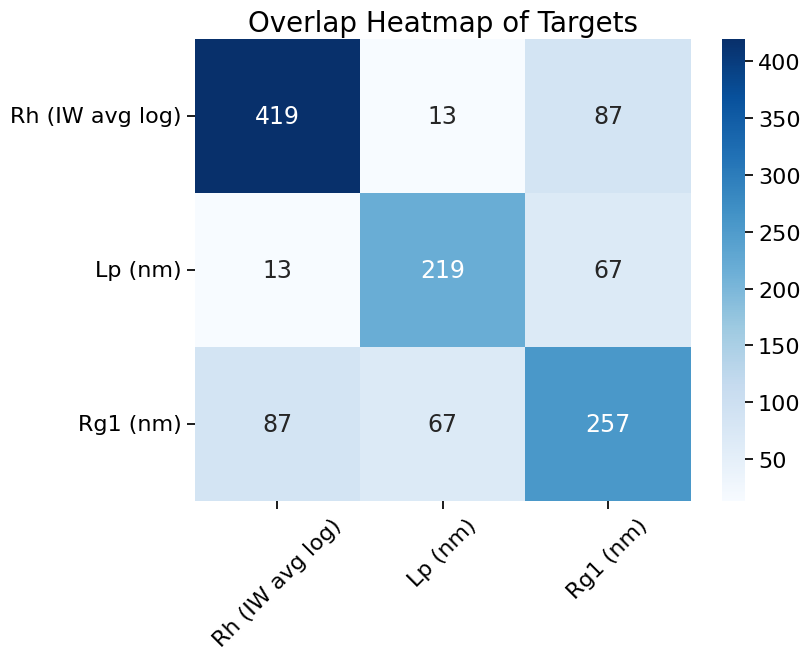

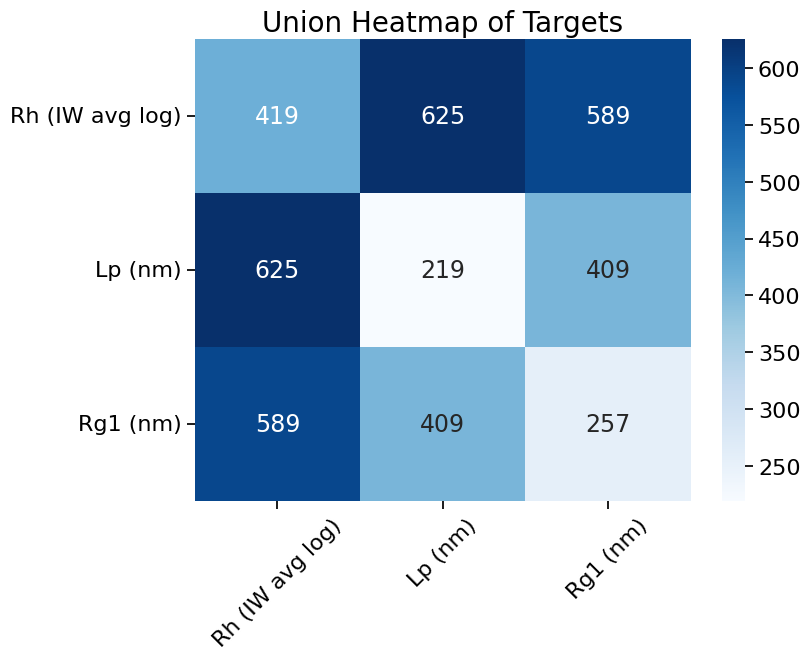

In [255]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = working_data

columns = ["Rh (IW avg log)", "Lp (nm)", "Rg1 (nm)"]

overlap_counts = {}
union_counts = {}

for col1 in columns:
    overlap_counts[col1] = {}
    union_counts[col1] = {}
    for col2 in columns:
        overlap_counts[col1][col2] = (df[col1].notnull() & df[col2].notnull()).sum()
        union_counts[col1][col2] = (df[col1].notnull() | df[col2].notnull()).sum()

overlap_df = pd.DataFrame(overlap_counts)
union_df = pd.DataFrame(union_counts)

def plot_heatmap(heat_df, title):
  plt.figure(figsize=(8, 6))
  sns.heatmap(heat_df, annot=True, cmap="Blues", fmt="d", cbar=True, annot_kws={"size": 17})
  plt.title(title)
  plt.xticks(rotation=45, fontsize=16)
  plt.yticks(rotation=0, fontsize=16)
  cbar = plt.gca().collections[0].colorbar

  cbar.ax.tick_params(labelsize=16)
  plt.show()


plot_heatmap(overlap_df,title="Overlap Heatmap of Targets")
plot_heatmap(union_df,title="Union Heatmap of Targets")

## missing values

In [256]:
def missing_percent_and_points(df:pd.DataFrame, mssing_threshold:int):
  missing_percentage: pd.Series = df.isnull().sum().sort_values(ascending=False)*100/len(df)
  missing_points: pd.Series = df.isnull().sum().sort_values(ascending=False)

  list_param: list[str] = missing_percentage.index.to_list()
  missed_values_percent: list[float] = missing_percentage.to_list()

  missed_points_values: list = missing_points.to_list()

  mis_df = pd.DataFrame({
    "Parameters": list_param,
    "missed_Percentage": missed_values_percent,
    "missing_Points": missed_points_values
     })
  mis_df= mis_df[mis_df['missed_Percentage']<=mssing_threshold]
  mis_df['availability_Percentage'] = 100 - mis_df['missed_Percentage']

  return mis_df

In [257]:
def number_percent_missing_data(df: pd.DataFrame,
                                features_column: str,
                                x_label: str,
                                left_y_label: str,
                                left_data: str,
                                right_y_label: str,
                                right_data: str,
                                title: str):
    # Filter DataFrame to include only non-zero missing percentages and points
    df_filtered = df[(df[left_data] > 0) & (df[right_data] > 0)]

    if df_filtered.empty:
        print("No parameters with non-zero missing data.")
        return

    fig, ax1 = plt.subplots(figsize=(12, 10))

    ax1.bar(df_filtered[features_column], df_filtered[left_data], color='gray', label='Missing')
    ax1.set_xlabel(x_label, fontsize=22, fontweight='bold')
    ax1.set_ylabel(left_y_label, fontsize=22, fontweight='bold')
    ax1.set_title(title, fontsize=24, fontweight='bold')
    ax1.set_xticklabels(df_filtered[features_column], rotation=45, ha='right', fontsize=18)
    ax1.tick_params(axis='y', labelsize=22)  # Increase x and y tick label size

    # Draw a horizontal dashed line at 30%
    ax1.axhline(y=30, color='r', linestyle='--', linewidth=2, label='30% Threshold')

    ax1_twin = ax1.twinx()
    ax1_twin.set_ylabel(right_y_label, fontsize=22, fontweight='bold')
    ax1_twin.set_ylim(0, max(df[right_data]) + 100)
    ax1_twin.tick_params(axis='y', labelsize=22)  # Increase y-axis tick label size for twin axis

    # Optional: Add a legend to explain the threshold line
    ax1.legend(loc='upper right', fontsize=18)

    plt.tight_layout()
    plt.show()


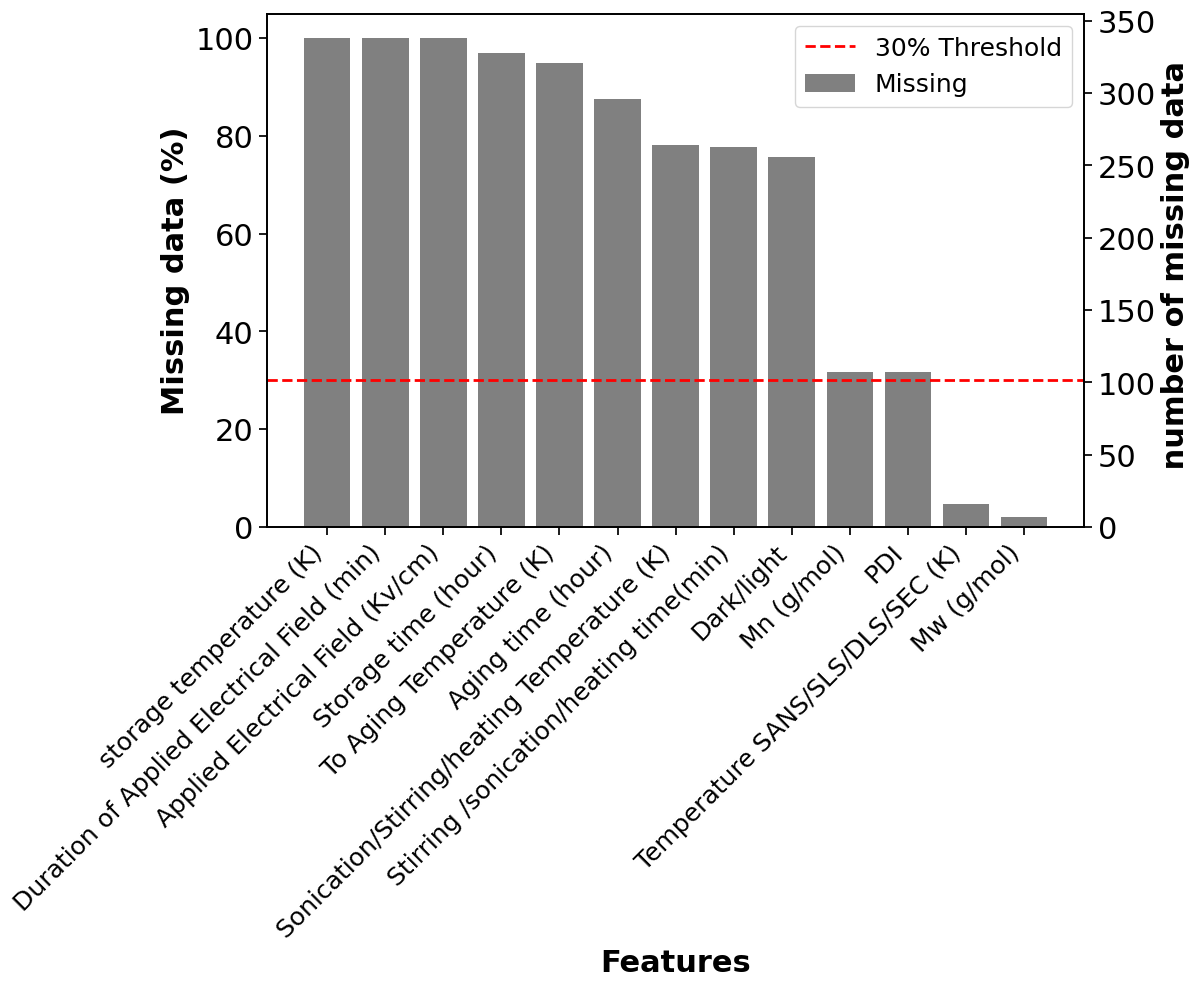

In [258]:
# Rg data
df_miss_under_all = missing_percent_and_points(Rg_data[missing_features_to_analyze], mssing_threshold=100)
df_miss_under_all["Parameters"] = df_miss_under_all["Parameters"].str.replace(r"^Merged\s*", "", regex=True)

# Now plot again
number_percent_missing_data(df=df_miss_under_all,
                            features_column="Parameters",
                            x_label='Features',
                            left_y_label='Missing data (%)',
                            left_data='missed_Percentage',
                            right_y_label=' number of missing data',
                            right_data="missing_Points",
                            title="")


In [259]:
def plot_missing_feature_per_polymer(df: pd.DataFrame, feature: str, figsize=(10, 5), fontsize=12):
    """
    Plots a bar chart of the number of missing values of a given feature per polymer.

    Parameters:
    - df: input DataFrame with 'canonical_name' and the target feature
    - feature: column name to check for missing values (e.g., 'Mn', 'PDI')
    - figsize: tuple indicating figure size
    - fontsize: integer font size for titles and labels
    """
    # Count missing values grouped by polymer
    missing_counts = df[df[feature].isna()].groupby('canonical_name').size()

    # Filter only polymers with missing values
    if missing_counts.empty:
        print(f"No missing values found for feature: {feature}")
        return

    # Plot
    plt.figure(figsize=figsize)
    colors = sns.color_palette("Set2")
    plt.bar(missing_counts.index, missing_counts.values/(len(df))*100,color=colors[7])
    plt.title(f'Missing Values of {feature} per Polymer', fontsize=fontsize+2,fontweight='bold')
    plt.ylabel('Missing (%)', fontsize=fontsize,fontweight='bold')
    plt.xlabel('Polymer', fontsize=fontsize,fontweight='bold')
    plt.xticks(rotation=45, fontsize=fontsize-1)
    plt.ylim(0,20)
    plt.yticks(fontsize=fontsize-1)
    plt.tight_layout()
    plt.show()


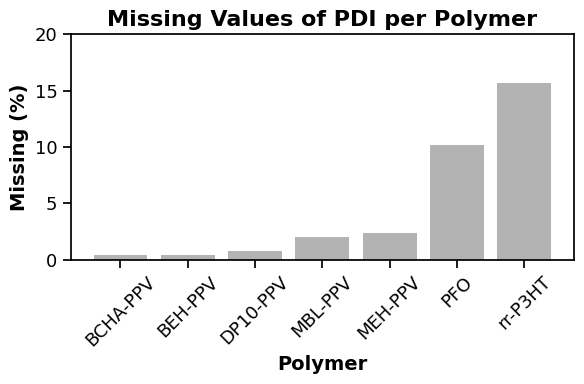

In [260]:
plot_missing_feature_per_polymer(Rg_data, feature='PDI', fontsize=14, figsize=(6, 4))

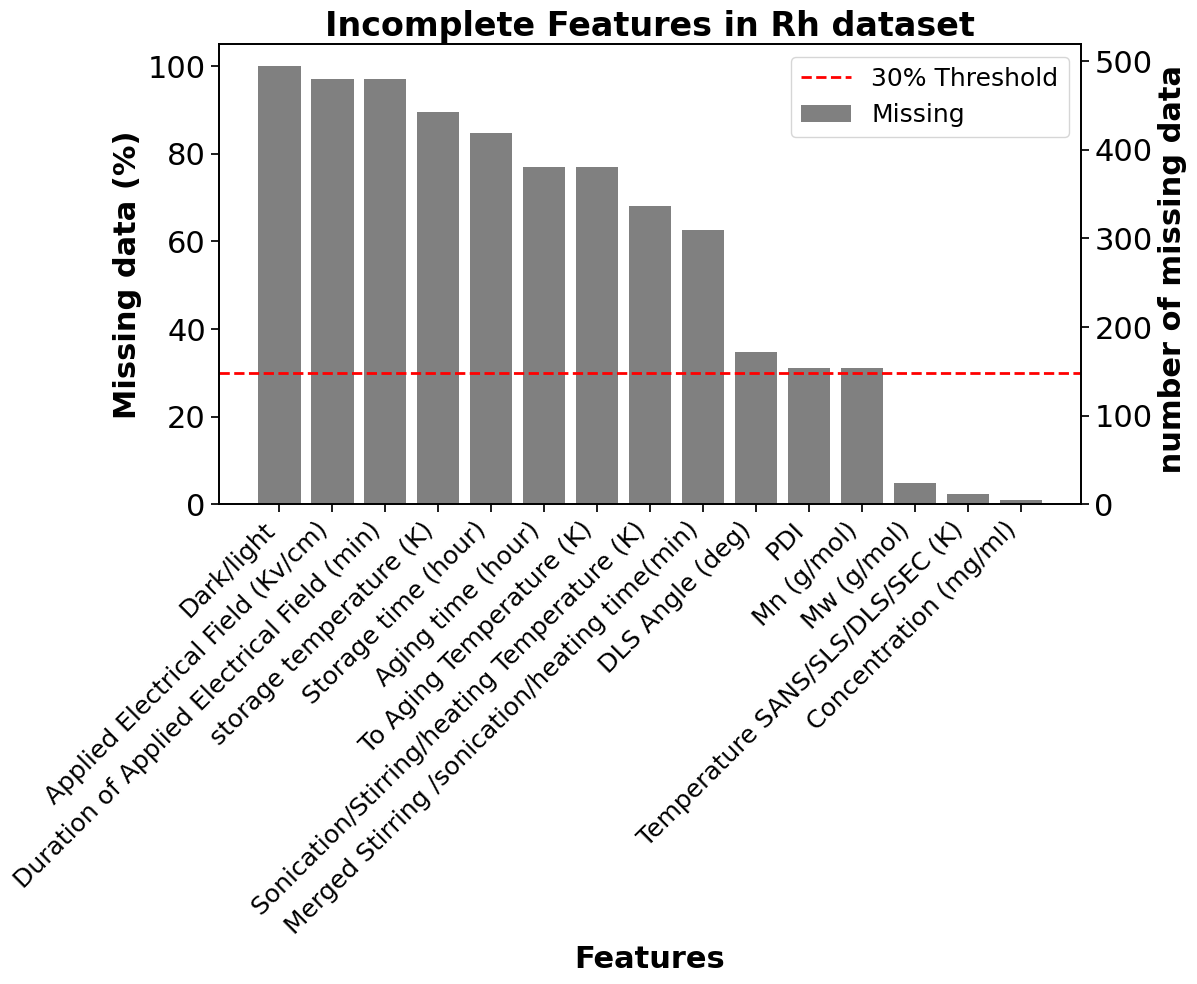

In [261]:
# Rh data
df_miss_under_all = missing_percent_and_points(Rh_data[missing_features_to_analyze+['DLS Angle (deg)']], mssing_threshold=100)
number_percent_missing_data(df=df_miss_under_all,
                            features_column="Parameters",
                            x_label='Features',
                            left_y_label='Missing data (%)',
                            left_data='missed_Percentage',
                            right_y_label=' number of missing data',
                            right_data="missing_Points",
                            title="Incomplete Features in Rh dataset")

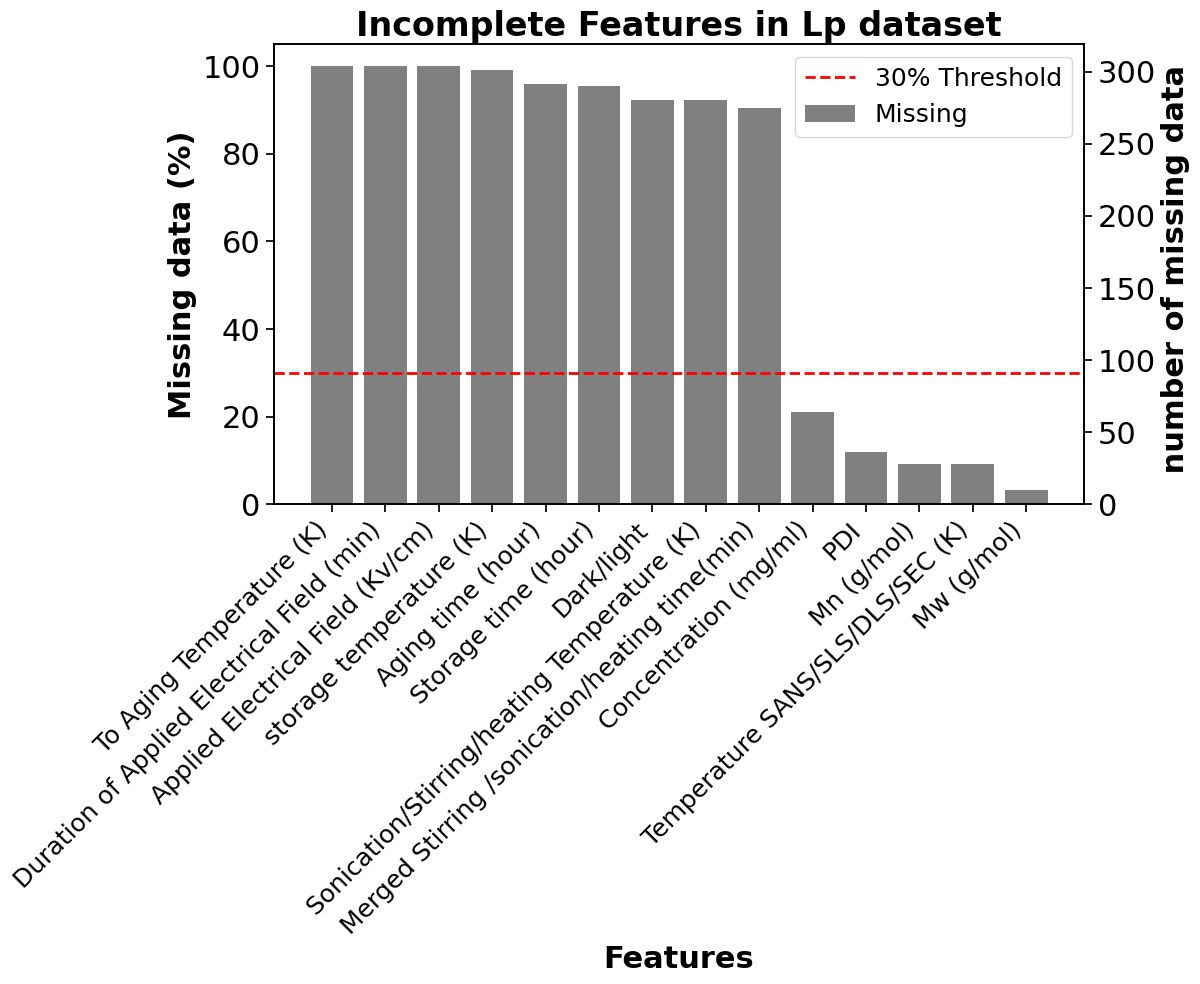

In [262]:
# Lp data
df_miss_under_all = missing_percent_and_points(Lp_data[missing_features_to_analyze], mssing_threshold=100)
number_percent_missing_data(df=df_miss_under_all,
                            features_column="Parameters",
                            x_label='Features',
                            left_y_label='Missing data (%)',
                            left_data='missed_Percentage',
                            right_y_label=' number of missing data',
                            right_data="missing_Points",
                            title="Incomplete Features in Lp dataset")

In [263]:
def available_percent_and_points(df: pd.DataFrame, availability_threshold: int):
    available_percentage = df.notnull().sum().sort_values(ascending=False) * 100 / len(df)
    available_points = df.notnull().sum().sort_values(ascending=False)

    list_param = available_percentage.index.to_list()
    available_values_percent = available_percentage.to_list()
    available_points_values = available_points.to_list()

    avail_df = pd.DataFrame({
        "Parameters": list_param,
        "available_Percentage": available_values_percent,
        "available_Points": available_points_values
    })

    # Filter based on the availability threshold
    avail_df = avail_df[avail_df["available_Percentage"] >= availability_threshold]

    # Now sort by the length of the 'Parameters' strings
    avail_df = avail_df.sort_values(by="Parameters", key=lambda x: x.str.len(), ascending=True)

    return avail_df


def number_percent_available_data(df: pd.DataFrame,
                                  features_column: str,
                                  x_label: str,
                                  left_y_label: str,
                                  left_data: str,
                                  right_y_label: str,
                                  right_data: str,
                                  title: str,
                                  fontsize=16):
    # Filter DataFrame to include only parameters with non-zero availability
    df_filtered = df[(df[left_data] > 0) & (df[right_data] > 0)]

    if df_filtered.empty:
        print("No parameters with available data.")
        return

    fig, ax1 = plt.subplots(figsize=(8, 8))

    ax1.bar(df_filtered[features_column], df_filtered[left_data],
            color=sns.color_palette("Set2")[2], label='Available')
    ax1.set_xlabel(x_label, fontsize=fontsize, fontweight='bold')
    ax1.set_ylabel(left_y_label, fontsize=fontsize, fontweight='bold')
    ax1.set_title(title, fontsize=fontsize+2, fontweight='bold')
    ax1.set_xticklabels(df_filtered[features_column], rotation=45, ha='right', fontsize=fontsize-2)
    ax1.set_ylim(0, 30)
    ax1.tick_params(axis='both', labelsize=fontsize-2)

    ax1_twin = ax1.twinx()
    ax1_twin.set_ylabel(right_y_label, fontsize=fontsize, fontweight='bold')
    ax1_twin.tick_params(axis='both', labelsize=fontsize-2)

    # ax1.legend(loc='upper right', fontsize=18)

    plt.tight_layout()
    plt.show()


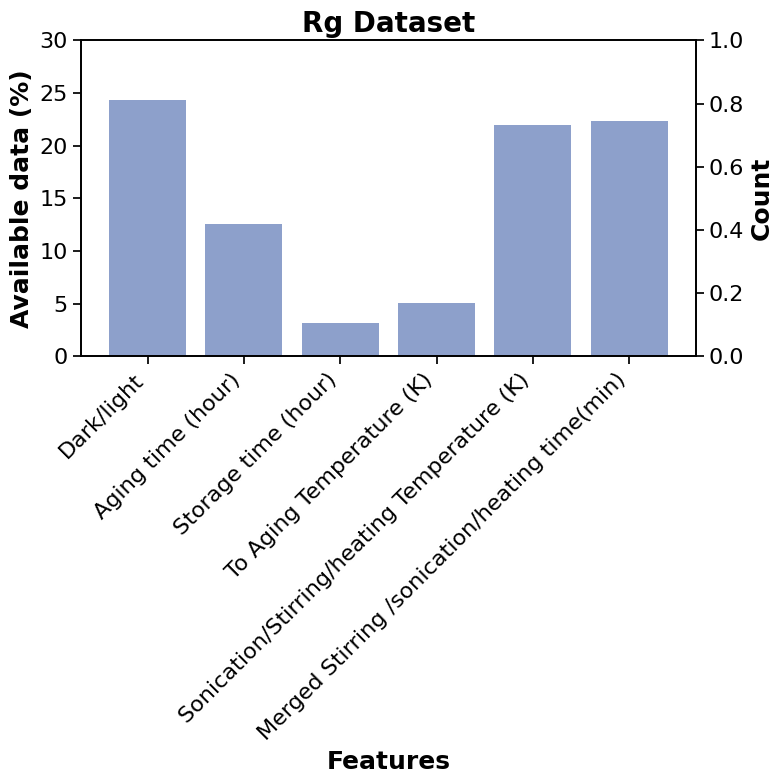

In [264]:
available_feats_to_analyze = list(set(missing_features_to_analyze) - set([
    'Mw (g/mol)',
    'Mn (g/mol)',
    'PDI',
    'Concentration (mg/ml)',
    'Temperature SANS/SLS/DLS/SEC (K)',
    'Ra',
    'Solvent(s)'
]))
# available_feats_to_analyze = sorted(available_feats_to_analyze, key=len)
# print(available_feats_to_analyze)

df_avail = available_percent_and_points(Rg_data[available_feats_to_analyze], availability_threshold=0)  # Adjust threshold if needed
number_percent_available_data(df=df_avail,
                              features_column="Parameters",
                              x_label='Features',
                              left_y_label='Available data (%)',
                              left_data='available_Percentage',
                              right_y_label='Count',
                              right_data="available_Points",
                              title="Rg Dataset",
                              fontsize=18)

## Pair plot with correlation plot

In [265]:
def transform_data(df, threshold,on_off:bool):
    """
    Applies log transformation to columns exceeding the given range threshold
    and renames transformed columns to include "log" in their names.
    """
    df_transformed = df.copy()
    col_name_map = {}  # Map original names to new names
    for col in df.columns:
        col_range = df[col].max() - df[col].min()
        if on_off is True:
          if col_range > threshold:
              new_col_name = f"log10({col})"
              df_transformed[new_col_name] = np.log10(df[col])
              print(f"Log transformation applied to '{col}' (Range: {col_range:.2f})")
              col_name_map[col] = new_col_name
              df_transformed.drop(columns=[col], inplace=True)
    return df_transformed, col_name_map


def corrfunc(x, y, **kwds):
    """
    Computes and visualizes Spearman correlation on the original data.
    """
    # Access the original DataFrame and column name mapping from kwds
    orig_df = kwds['orig_df']
    col_name_map = kwds['col_name_map']

    # Map transformed column names back to original names
    orig_x_name = next((key for key, value in col_name_map.items() if value == x.name), x.name)
    orig_y_name = next((key for key, value in col_name_map.items() if value == y.name), y.name)

    # Get the original columns
    orig_x = orig_df[orig_x_name]
    orig_y = orig_df[orig_y_name]

    # Handle NaNs for original data
    valid_idx = ~np.logical_or(np.isnan(orig_x), np.isnan(orig_y))
    orig_x, orig_y = orig_x[valid_idx], orig_y[valid_idx]

    # Compute correlation
    r, _ = spearmanr(orig_x, orig_y)

    # Set up the plot
    cmap = kwds.get('cmap', plt.get_cmap('coolwarm'))
    norm = kwds.get('norm', plt.Normalize(vmin=-1, vmax=1))
    ax = plt.gca()
    sns.despine(ax=ax)

    facecolor = cmap(norm(r))
    ax.set_facecolor(facecolor)
    lightness = (max(facecolor[:3]) + min(facecolor[:3])) / 2
    ax.annotate(f"{r:.2f}", xy=(0.5, 0.5), xycoords=ax.transAxes,
                color='white' if lightness < 0.7 else 'black',
                ha='center', va='center', fontsize=kwds['fontsize']+1)



def draw_heat_pair_plot(df: pd.DataFrame, parameters: list, title: str = '',
                        threshold=100,fig_size=(8, 8),fontsize=20):
    """
    Creates a heat pair plot with optional log transformation for features
    exceeding a specified range threshold.
    """
    # Transform data and rename columns as needed
    transformed_df, col_name_map = transform_data(df[parameters], threshold=threshold,on_off=False)

    # Create PairGrid with transformed data
    g = sns.PairGrid(transformed_df)
    g.map_lower(plt.scatter, s=10)
    g.map_diag(sns.histplot, kde=False)

    # Pass original data and column name mapping to `corrfunc`
    g.map_upper(corrfunc, cmap=plt.get_cmap('coolwarm'), norm=plt.Normalize(vmin=-1, vmax=1),
                orig_df=df[parameters], col_name_map=col_name_map,fontsize=fontsize)

    for i in range(1, len(parameters)):  # All columns except the first
        for j in range(len(parameters)):  # All rows including top histogram
            ax = g.axes[j, i]
            ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    # Ensure that the first column (left y-axis) and last row (bottom x-axis) keep their ticks
    # for i in range(len(parameters)):
    #     g.axes[i, 0].yaxis.set_tick_params(which='both', length=4)  # Left y-axis
    #     g.axes[-1, i].xaxis.set_tick_params(which='both', length=4)  # Bottom x-axis




    g.fig.set_size_inches(*fig_size)

    # Adjust ticks and labels for size and update column names
    for ax, col in zip(g.axes[-1, :], transformed_df.columns):
        ax.set_xlabel(col, fontsize=fontsize+2, rotation=80)  # Set x label font
    for ax, row in zip(g.axes[:, 0], transformed_df.columns):
        ax.set_ylabel(row, fontsize=fontsize+2, rotation=0)  # Set y label font
        ax.yaxis.get_label().set_horizontalalignment('right')

    # Set the figure title (optional)
    g.fig.suptitle(title, fontsize=fontsize+30, y=1.07)

    g.fig.subplots_adjust(wspace=0.01, hspace=0.01)  # Equal spacing in both directions
    plt.show()


In [266]:
corr_feats_polysize = ['Xn','Mw (g/mol)', 'PDI','polymer dP','polymer dD','polymer dH','Ra']
corr_feats_solution = ['Concentration (mg/ml)', 'Temperature SANS/SLS/DLS/SEC (K)',
                        'solvent dP', 'solvent dD', 'solvent dH']


all = ['Xn','Mw (g/mol)', 'PDI','polymer dP','polymer dD','polymer dH','solvent dP', 'solvent dD', 'solvent dH',
                       'Concentration (mg/ml)', 'Temperature SANS/SLS/DLS/SEC (K)','abs(solvent dD - polymer dD)',
                      'abs(solvent dP - polymer dP)',
                      'abs(solvent dH - polymer dH)','Ra']

### Before Imputation

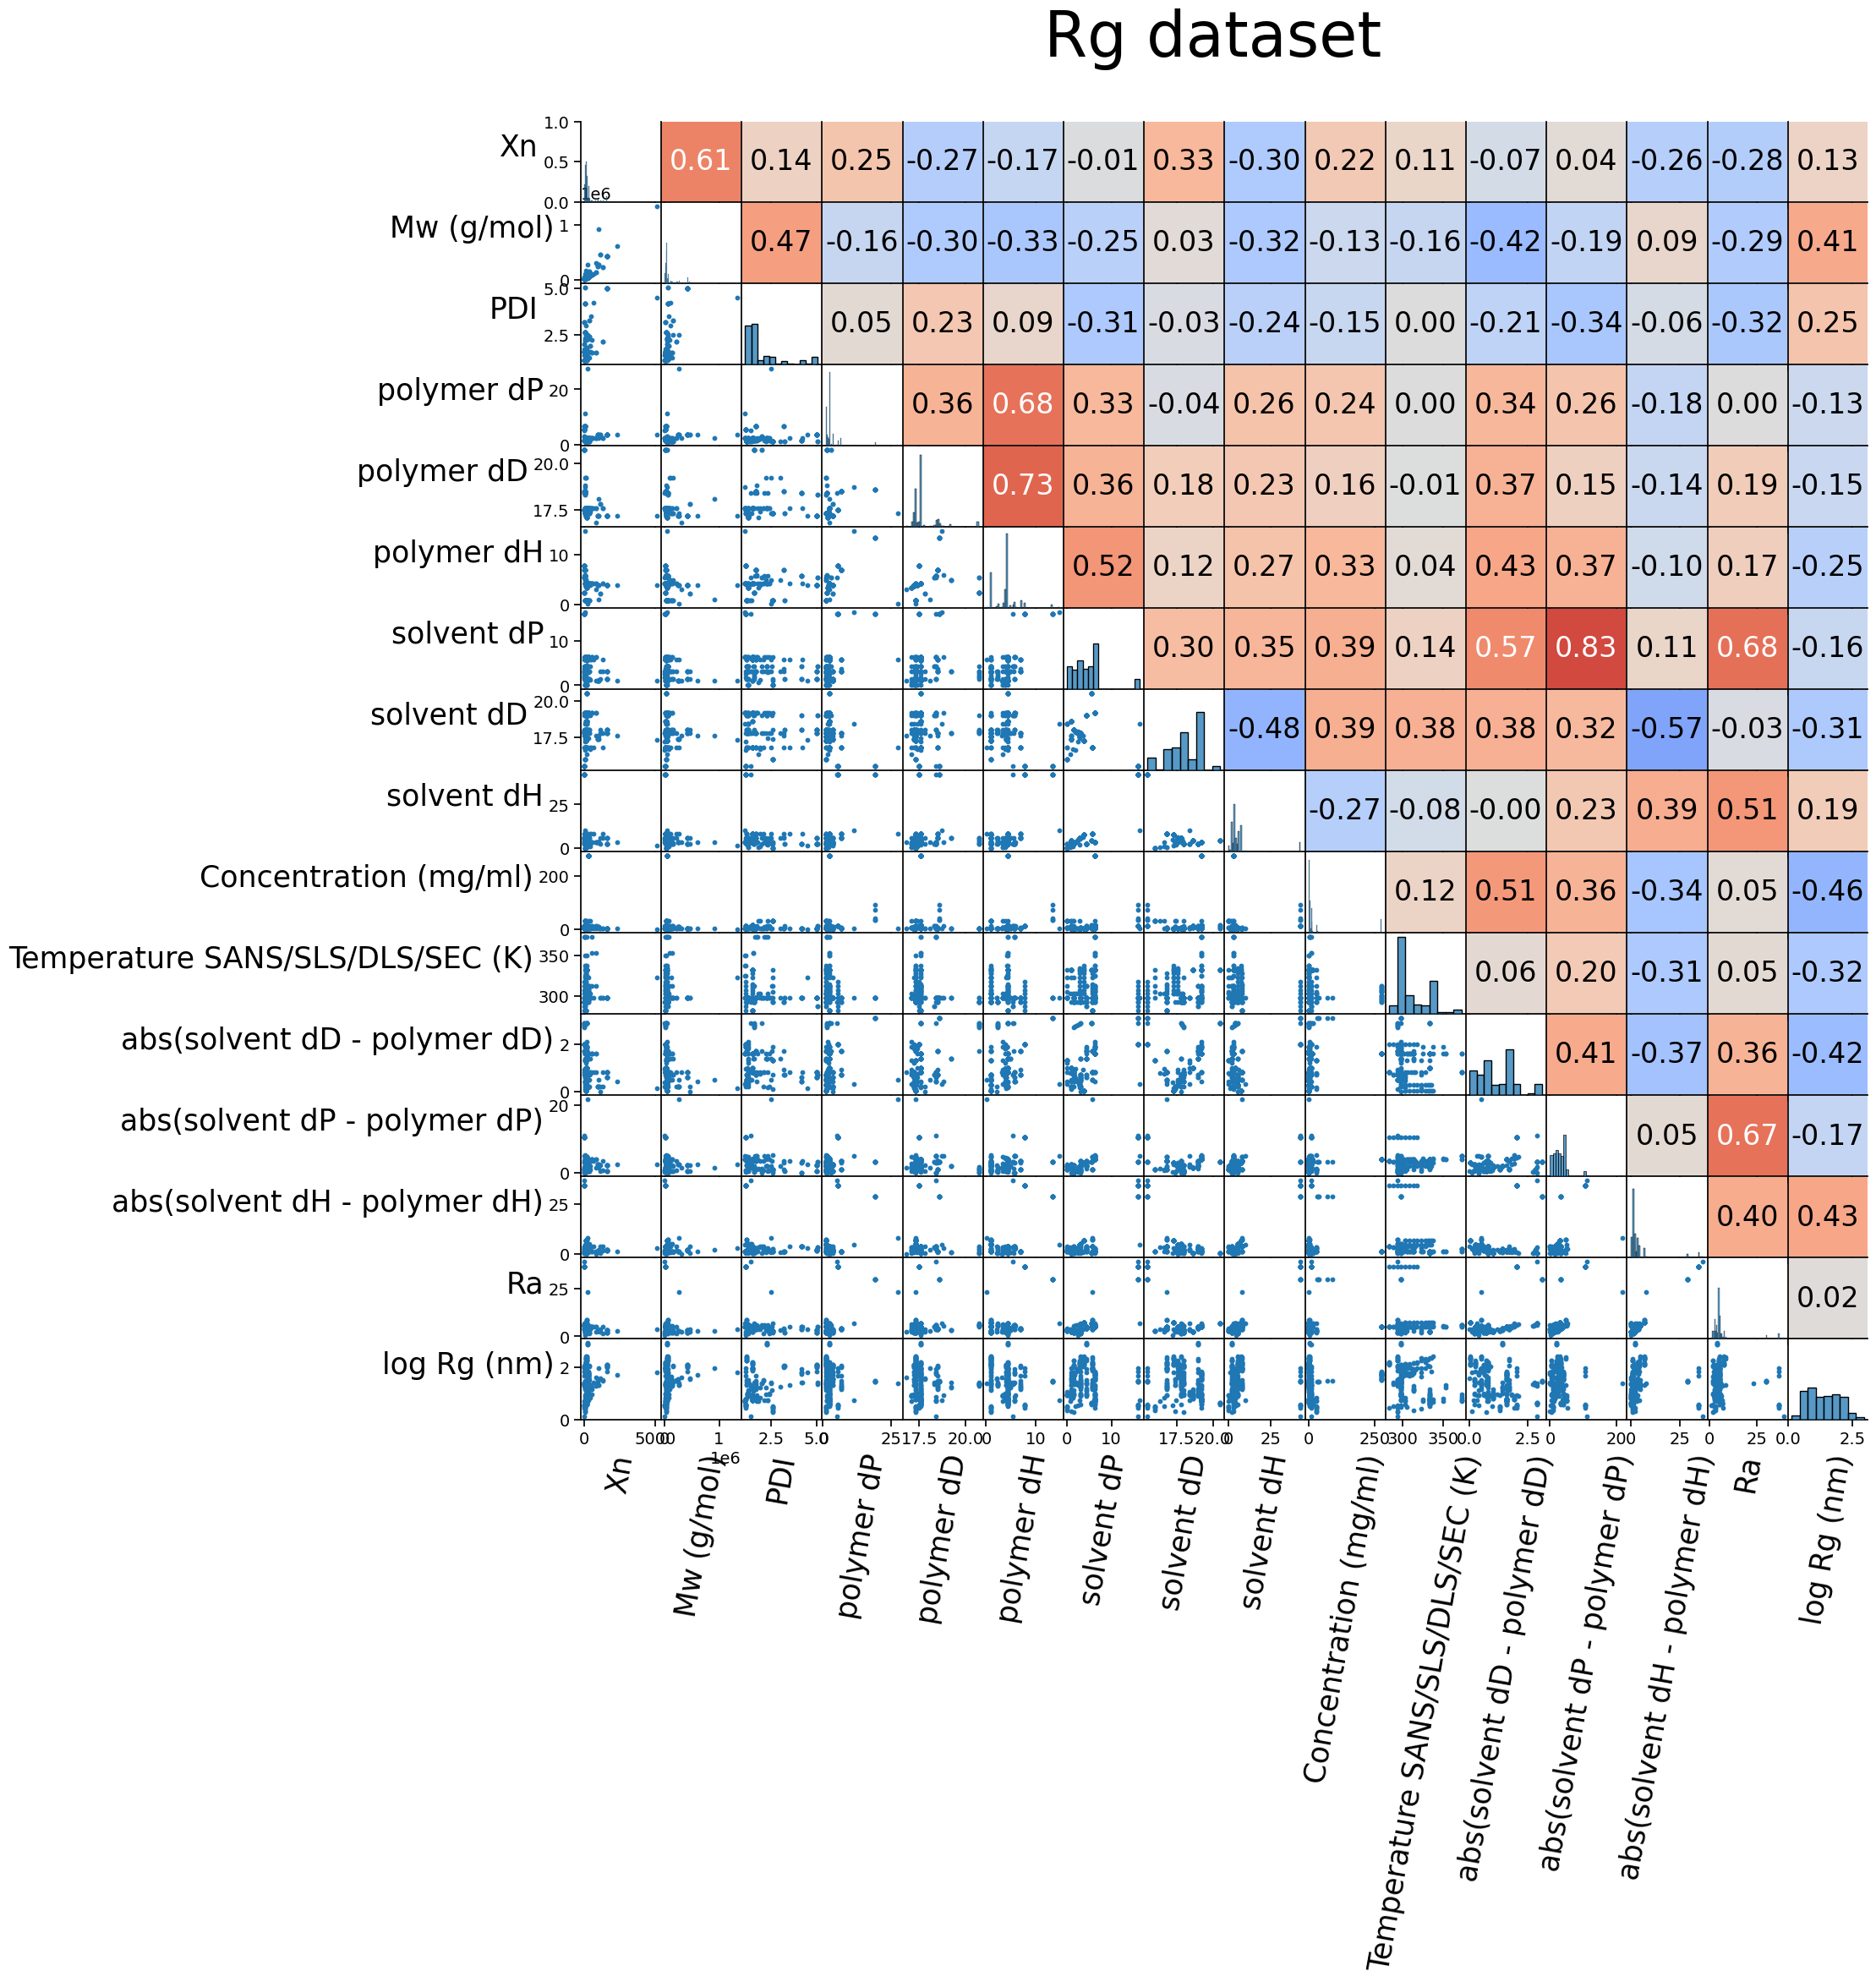

In [268]:
# Rg dataset
draw_heat_pair_plot(df=Rg_data,parameters=all+['log Rg (nm)'], title="Rg dataset",threshold=200,fig_size=(16, 16),fontsize=23)

In [139]:
# Rh dataset
# draw_heat_pair_plot(df=Rh_data ,parameters=corr_feats_solution+['log Rh (nm)'], title="spearman correlation-pair plot of Rh dataset",threshold=200,fig_size=(12, 12))

In [140]:
# draw_heat_pair_plot(df=Lp_data ,parameters=corr_feats_solution+['Lp (nm)'], title="spearman correlation-pair plot of Lp dataset",threshold=200,fig_size=(12, 12))

### After imputation

In [141]:
# Rg dataset
# draw_heat_pair_plot(df=clean_rg,parameters=all+['log Rg (nm)'], title="Rg dataset",threshold=100,fig_size=(16, 16),fontsize=23)

# draw_heat_pair_plot(df=imputed_Rg_data,parameters=corr_feats_polysize+['log Rg (nm)'], title="Polymer related features (Rg dataset)",threshold=200,fig_size=(10, 10))
# draw_heat_pair_plot(df=imputed_Rg_data,parameters=corr_feats_solution+['log Rg (nm)'], title="Eexperimental features (Rg dataset)",threshold=200,fig_size=(9, 9))


In [142]:
# imputed Rh
# draw_heat_pair_plot(df=imputed_Rh_data ,parameters=corr_feats_polysize+['log Rh (nm)'], title="spearman correlation-pair plot of Rh dataset",threshold=200,fig_size=(10, 10))
# draw_heat_pair_plot(df=imputed_Rh_data ,parameters=corr_feats_solution+['log Rh (nm)'], title="spearman correlation-pair plot of Rh dataset",threshold=200,fig_size=(12, 12))

In [143]:
# imputed Lp
# draw_heat_pair_plot(df=imputed_Lp_data ,parameters=corr_feats_polysize+['Lp (nm)'], title="spearman correlation-pair plot of Lp dataset",threshold=200,fig_size=(10, 10))
# draw_heat_pair_plot(df=imputed_Lp_data ,parameters=corr_feats_solution+['Lp (nm)'], title="spearman correlation-pair plot of Lp dataset",threshold=200,fig_size=(12, 12))

In [144]:
# def draw_pairplot(df: pd.DataFrame, parameters: list, hue: str = None, palette: str = "husl",title: str = "")->None:
#     """
#     Draws a pair plot of the specified parameters from the DataFrame.

#     Parameters:
#     - df: pd.DataFrame - The DataFrame containing the data to plot.
#     - parameters: list - A list of column names to include in the pair plot.
#     - hue: str, optional - The column name for color encoding. Default is None.
#     - palette: str, optional - The color palette to use. Default is "husl".
#     """
#     data_to_plot = df[parameters]
#     plt.figure(figsize=(20, 20))
#     pairplot = sns.pairplot(data=data_to_plot, hue=hue, palette=palette)
#     if title:
#         pairplot.fig.suptitle(title, fontsize=45, fontweight='bold',y=1.01)

#     for ax in pairplot.axes.flatten():
#       ax.set_xlabel(ax.get_xlabel(), fontsize=30, fontweight='bold',rotation=90)  # Set x label font
#       ax.set_ylabel(ax.get_ylabel(), fontsize=30, fontweight='bold',rotation=0)  # Set y label font
#       ax.yaxis.get_label().set_horizontalalignment('right')
#     plt.tight_layout()
#     # plt.subplots_adjust(left=0.15, right=0.85, top=0.9, bottom=0.15)
#     plt.show()

## Imputing the aging stuff

In [269]:
features = [
  'name',
  'canonical_name',
  'Mw (g/mol)',
  'Mn (g/mol)',
  'PDI',
  'Regioregularity R%',
  'DP',
  'Dark/light',
  'Applied Electrical Field (Kv/cm)',
  'Duration of Applied Electrical Field (min)',
  'DLS Angle (deg)',
  'Concentration (mg/ml)',
  'Temperature SANS/SLS/DLS/SEC (K)',
  'Aging time (hour)',
  'To Aging Temperature (K)',
  # 'Sonication time (min)',
  'Sonication/Stirring/heating Temperature (K)',
  'Merged Stirring /sonication/heating time(min)',
  'storage temperature (K)',
  'Storage time (hour)',
  'Solvent(s)',
  'A2 (mol dm3/g^2)',
  'Ra',
  'solvent dP',
  'polymer dP',
  'solvent dD',
  'polymer dD',
  'solvent dH',
  'polymer dH',
  'Rh (IW avg log)',
  'Rg1 (nm)',
  'Lp (nm)',
]

missing_features_to_analyze = [
  'Mw (g/mol)',
  'Mn (g/mol)',
  'PDI',
  'Solvent(s)',
  'Temperature SANS/SLS/DLS/SEC (K)',
  'Concentration (mg/ml)',
  'Dark/light',
  'Applied Electrical Field (Kv/cm)',
  'Duration of Applied Electrical Field (min)',
  'storage temperature (K)',
  'Storage time (hour)',
  'Aging time (hour)',
  'To Aging Temperature (K)',
  'Sonication/Stirring/heating Temperature (K)',
  'Merged Stirring /sonication/heating time(min)',


]
features_to_analyze = [
    'Mw (g/mol)',
    'Mn (g/mol)',
    'PDI',
    'Concentration (mg/ml)',
    'Temperature SANS/SLS/DLS/SEC (K)','Ra',
    'solvent dP',
    'polymer dP',
    'solvent dD',
    'polymer dD',
    'solvent dH',
    'polymer dH',
    'Rh (IW avg log)',
    'Rg1 (nm)',
    'Lp (nm)'
]


In [270]:
sensetive_processing_parameters = [
  'Dark/light',
  'Applied Electrical Field (Kv/cm)',
  'Duration of Applied Electrical Field (min)',
  'DLS Angle (deg)',
  'Aging time (hour)',
  'To Aging Temperature (K)',
  # 'Stirring /sonication/heating time(min)',
  # 'Sonication time (min)',
  'Sonication/Stirring/heating Temperature (K)',
  'Merged Stirring /sonication/heating time(min)',
  'storage temperature (K)',
  'Storage time (hour)',
]

sensetive_processing_parameters_rg = [x for x in sensetive_processing_parameters if x != 'DLS Angle (deg)']


In [271]:
def encode_light_dark(value):
    value_str = str(value).strip().lower()
    if value_str == 'light':
        return 1
    elif value_str == 'dark' or value_str =='dark2':
        return 0
    else:
        return value

In [272]:
##### Some cleaning for converting str to numerical like overnight -> 12 h, 4-5 -> mean of 4,5.
def convert_str_to_num(value, colname):
    if isinstance(value, (int, float)):
        return value
    if '-' in str(value) or '−' in str(value):  # Added handling for en dash character
        parts = str(value).replace('−', '-').split('-')  # Replacing en dash with hyphen
        if len(parts) == 2:  # If it's in the format number1-number2
            num1, num2 = map(float, parts)
            return (num1 + num2) / 2
    if 'overnight' in str(value):
        if 'min' in colname.lower():
            return 16 * 60  # 12 hours in minutes
        elif 'hour' in colname.lower():
            return 16
    else:
      return value

In [273]:
# Rh_working_data = imputed_Rh_data.copy()
Rg_working_data = clean_rg.copy()


Rg_working_data['Dark/light'] = Rg_working_data['Dark/light'].apply(encode_light_dark)
for col in sensetive_processing_parameters_rg:
        Rg_working_data[col] = Rg_working_data[col].apply(lambda val: convert_str_to_num(val, col))
        print(f"{col}: {Rg_working_data[col].dtype}")


Dark/light: float64
Applied Electrical Field (Kv/cm): float64
Duration of Applied Electrical Field (min): float64
Aging time (hour): float64
To Aging Temperature (K): float64
Sonication/Stirring/heating Temperature (K): float64
Merged Stirring /sonication/heating time(min): float64
storage temperature (K): float64
Storage time (hour): float64


In [274]:
# Rh_size = len(Rh_working_data)
Rg_size = len(Rg_working_data)
# rh_rows_with_values = Rh_working_data[sensetive_processing_parameters].notna().any(axis=1).sum()
rg_rows_with_values = Rg_working_data[sensetive_processing_parameters_rg].notna().any(axis=1).sum()
# rh_counts_per_column = Rh_working_data[sensetive_processing_parameters].notna().sum()/Rh_size*100
rg_counts_per_column = Rg_working_data[sensetive_processing_parameters_rg].notna().sum()/Rg_size*100

# print(f"Size of Rh dataset: {Rh_size}")
print(f"Size of Rg dataset: {Rg_size}", "\n\n")
# print(f"Percentage of rows with a value in any of the specified columns in Rh dataset: {rh_rows_with_values / Rh_size * 100:.1f}%")
print(f"Percentage of rows with a value in any of the specified columns in Rg dataset: {rg_rows_with_values / Rg_size * 100:.1f}%\n\n")

# print("Available datapoints (%) for each feature in Rh dataset:\n")
# print(rh_counts_per_column.round(1).to_string(index=True, float_format="{:.1f}".format))

print("\n\nAvailable datapoints (%) for each feature in Rg dataset:\n")
print(rg_counts_per_column.round(1).to_string(index=True, float_format="{:.1f}".format))

Size of Rg dataset: 255 


Percentage of rows with a value in any of the specified columns in Rg dataset: 55.3%




Available datapoints (%) for each feature in Rg dataset:

Dark/light                                      24.3
Applied Electrical Field (Kv/cm)                 0.0
Duration of Applied Electrical Field (min)       0.0
Aging time (hour)                               12.5
To Aging Temperature (K)                         5.1
Sonication/Stirring/heating Temperature (K)     22.0
Merged Stirring /sonication/heating time(min)   22.4
storage temperature (K)                          0.0
Storage time (hour)                              3.1


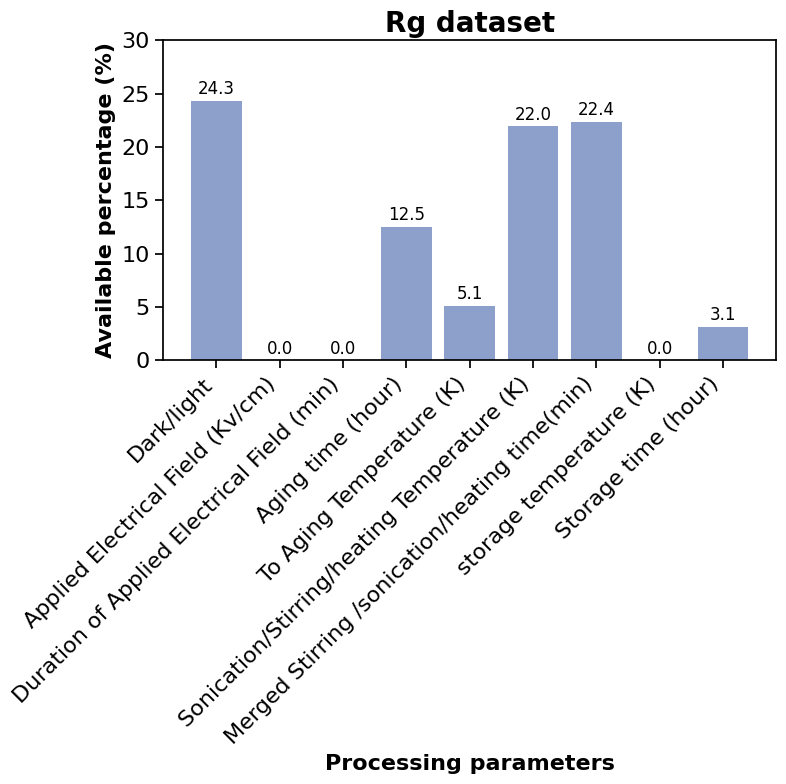

In [275]:
rg_counts_per_column = Rg_working_data[sensetive_processing_parameters_rg].notna().sum()/Rg_size*100
fig, ax = plt.subplots(figsize=(8,8))
color = sns.color_palette("Set2")[2]
bars = ax.bar(rg_counts_per_column.index, rg_counts_per_column.values, color=color)

# Add number labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01 * max(rg_counts_per_column.values),
            f'{height:.1f}', ha='center', va='bottom', fontsize=12)

# Customize plot
ax.set_xlabel('Processing parameters', fontsize=16,fontweight='bold')
ax.set_ylabel('Available percentage (%)', fontsize=16,fontweight='bold')
ax.set_title('Rg dataset', fontsize=20,fontweight='bold')
plt.xticks(rotation=45, ha='right',fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0,30)
plt.tight_layout()
plt.show()

In [276]:
mask = Rg_working_data['Storage time (hour)'].notna() & Rg_working_data['Aging time (hour)'].notna()
rows_with_both = Rg_working_data[mask]
rows_with_both

,name,Mw (g/mol),Mn (g/mol),PDI,Regioregularity R%,DP,SANS,SAXS/GWAXS,DLS,SLS,...,polymer dD,solvent dH,polymer dH,Ra,abs(solvent dD - polymer dD),abs(solvent dP - polymer dP),abs(solvent dH - polymer dH),Merged Stirring /sonication/heating time(min),Xn,log Rg (nm)


In [277]:
varied_processing_parameters = ['Dark/light',
                                # 'Applied Electrical Field (Kv/cm)',
                                # 'Duration of Applied Electrical Field (min)',
                                'Aging time (hour)',
                                'To Aging Temperature (K)',
                                'Sonication/Stirring/heating Temperature (K)',
                                'Merged Stirring /sonication/heating time(min)',
                                # 'storage temperature (K)',
                                # 'Storage time (hour)'
                                ]

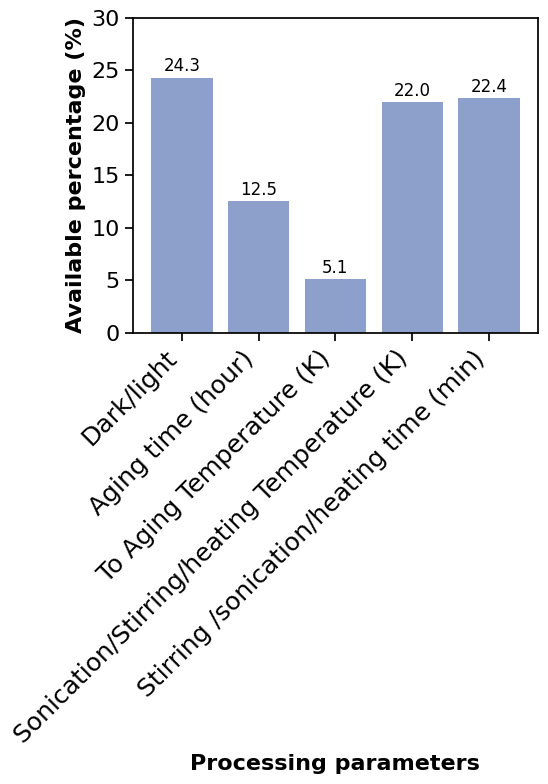

In [278]:
# Calculate available percentage for each processing parameter
rg_counts_per_column = Rg_working_data[varied_processing_parameters].notna().sum() / Rg_size * 100

# Clean labels:
# 1. Remove "Merged" if it's the first word
# 2. Add space before (min) if missing
rg_counts_per_column.index = (
    rg_counts_per_column.index
    .str.replace(r"^Merged\s*", "", regex=True)     # remove "Merged"
    .str.replace(r"\(min\)", " (min)", regex=True) # ensure space before (min)
)

# Plot
fig, ax = plt.subplots(figsize=(5.5,8))
color = sns.color_palette("Set2")[2]
bars = ax.bar(rg_counts_per_column.index, rg_counts_per_column.values, color=color)

# Add number labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height + 0.01 * max(rg_counts_per_column.values),
            f'{height:.1f}', ha='center', va='bottom', fontsize=12)

# Customize plot
ax.set_xlabel('Processing parameters', fontsize=16, fontweight='bold')
ax.set_ylabel('Available percentage (%)', fontsize=16, fontweight='bold')
ax.set_title('', fontsize=20, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(fontsize=16)
plt.ylim(0, 30)
plt.tight_layout()
plt.show()


In [279]:
# inputing incubation time as aging time in pBTTTC16 data
Rg_working_data.loc[135:136, 'Aging time (hour)'] = [0, 24]
cols_to_check = [
    'Concentration (mg/ml)',
    'Temperature SANS/SLS/DLS/SEC (K)',
    'Mw (g/mol)',
    'PDI',
    'Ra',
    'canonical_name'
]

df_unique = Rg_working_data.drop_duplicates(subset=cols_to_check)

In [280]:
duplicates_mask = Rg_working_data.duplicated(subset=cols_to_check, keep=False)
duplicates_df = Rg_working_data[duplicates_mask].copy()

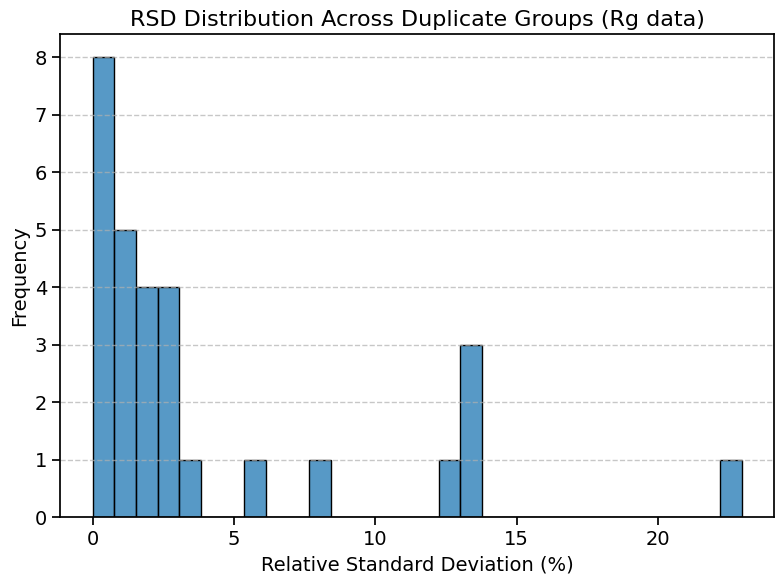

In [281]:
target = 'log Rg (nm)'
grouped = duplicates_df.groupby(cols_to_check)
rsd_list = []

for group_key, group_df in grouped:
    if len(group_df) > 1 and group_df[target].notna().all():
        mean_val = group_df[target].mean()
        std_val = group_df[target].std()
        if mean_val != 0:
            rsd = (std_val / mean_val) * 100
            rsd_list.append(rsd)

plt.figure(figsize=(8, 6))
sns.histplot(rsd_list, bins=30, kde=False)
plt.xlabel('Relative Standard Deviation (%)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title(f'RSD Distribution Across Duplicate Groups (Rg data)', fontsize=16)
plt.grid(axis = 'y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

                             Processing Parameter  Relative Std
0                               Aging time (hour)      1.789295
1                        To Aging Temperature (K)      1.789295
2                                      Dark/light     13.157063
3                                      Dark/light      1.149986
4                                      Dark/light     22.950156
5                                      Dark/light     13.295177
6                                      Dark/light      5.531560
7                                      Dark/light      2.789092
8                                      Dark/light     13.387792
9                                      Dark/light      8.121937
10                              Aging time (hour)      8.121937
11                                     Dark/light      1.118016
12                              Aging time (hour)      1.118016
13                                     Dark/light     12.760932
14                              Aging ti

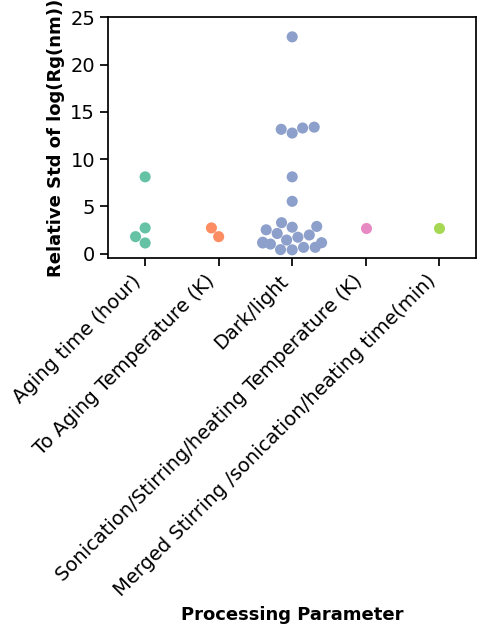

In [282]:
rsd_records = []
target = 'log Rg (nm)'

for _, group_df in grouped:
    if len(group_df) > 1 and group_df[target].notna().all():
        mean_val = group_df[target].mean()
        std_val = group_df[target].std()
        if mean_val != 0:
            rsd = (std_val / mean_val) * 100

            for param in varied_processing_parameters:
                if group_df[param].notna().all():
                    rsd_records.append({
                        "Processing Parameter": param,
                        "Relative Std": rsd
                    })

# Step 3: Create DataFrame and plot
rsd_df = pd.DataFrame(rsd_records)
print(rsd_df)
plt.figure(figsize=(5, 6.5))
sns.swarmplot(data=rsd_df, x="Processing Parameter", y="Relative Std", size=8,palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title("", fontsize=18,fontweight='bold')
plt.xlabel("Processing Parameter", fontsize=13,fontweight='bold')
plt.ylabel("Relative Std of log(Rg(nm))", fontsize=13,fontweight='bold')# plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-.5,25)
plt.tight_layout()
plt.show()

In [283]:
# for _, group_df in grouped:
#     if len(group_df) > 1 and group_df[target].notna().all():
#       display(group_df[['name']+cols_to_check+varied_processing_parameters])

In [284]:
grouped = Rg_working_data.groupby(cols_to_check, as_index=False)

def collapse_group(group):
    row = group.iloc[0].copy()
    row['log Rg (nm)'] = group['log Rg (nm)'].mean()
    return row

collapsed_df = grouped.apply(collapse_group).reset_index(drop=True)
collapsed_df.to_pickle(data_folder/'Rg data with clusters melted duplicates.pkl')

In [285]:
Rg_with_cleaned_aging = Rg_working_data.copy()

In [286]:
varied_processing_parameters =[
    'Dark/light',
    'Aging time (hour)',
    'To Aging Temperature (K)',
    'Sonication/Stirring/heating Temperature (K)',
    'Merged Stirring /sonication/heating time(min)']

In [287]:
def plot_polymers_with_processing_missing(df: pd.DataFrame, features: list, figsize=(12, 6), fontsize=12):
    """
    Plots the number of missing entries in varied processing parameters per polymer,
    only for polymers that have at least one missing value in those features.

    Parameters:
    - df: DataFrame with 'canonical_name' and feature columns
    - features: list of processing-related features to check for missing values
    - figsize: size of the figure (width, height)
    - fontsize: font size for labels and title
    """
    missing_rows = df[features].isna().any(axis=1)

    polymer_missing_counts = df[missing_rows].groupby('canonical_name').size()

    if polymer_missing_counts.empty:
        print("No polymers with missing processing parameters.")
        return
    polymer_missing_counts = polymer_missing_counts.sort_values()
    plt.figure(figsize=figsize)
    colors = sns.color_palette("Set2")
    plt.bar(polymer_missing_counts.index, polymer_missing_counts.values/len(df)*100, color=colors[2])

    plt.title('Missing value at least in one of the processing parameters', fontsize=fontsize,fontweight='bold')
    plt.ylabel('Missing (%)', fontsize=fontsize,fontweight='bold')
    plt.xlabel('Polymer', fontsize=fontsize,fontweight='bold')
    plt.xticks(rotation=60, fontsize=fontsize -2.5)
    plt.yticks(fontsize=fontsize - 1)
    plt.ylim(0,50)
    plt.tight_layout()
    plt.show()

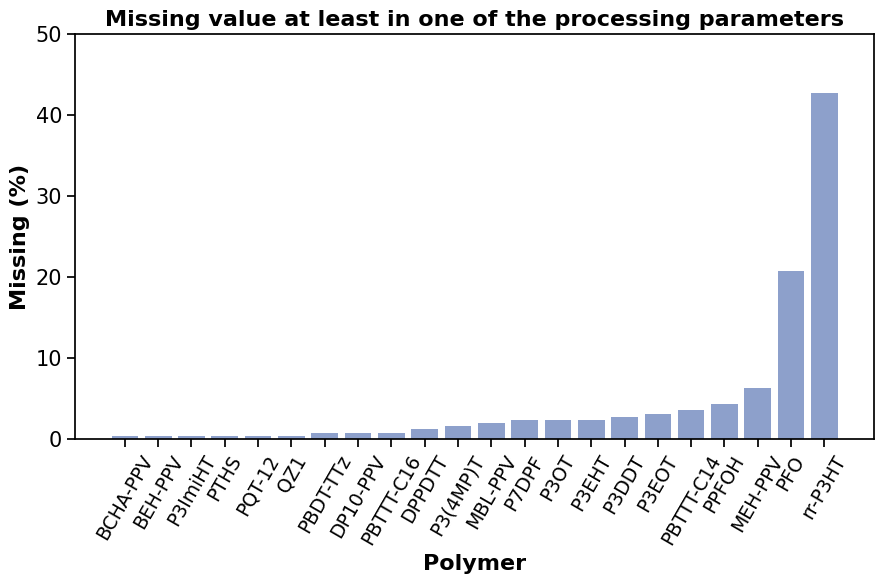

In [288]:
plot_polymers_with_processing_missing(Rg_with_cleaned_aging, varied_processing_parameters,figsize=(9,6),fontsize=16)

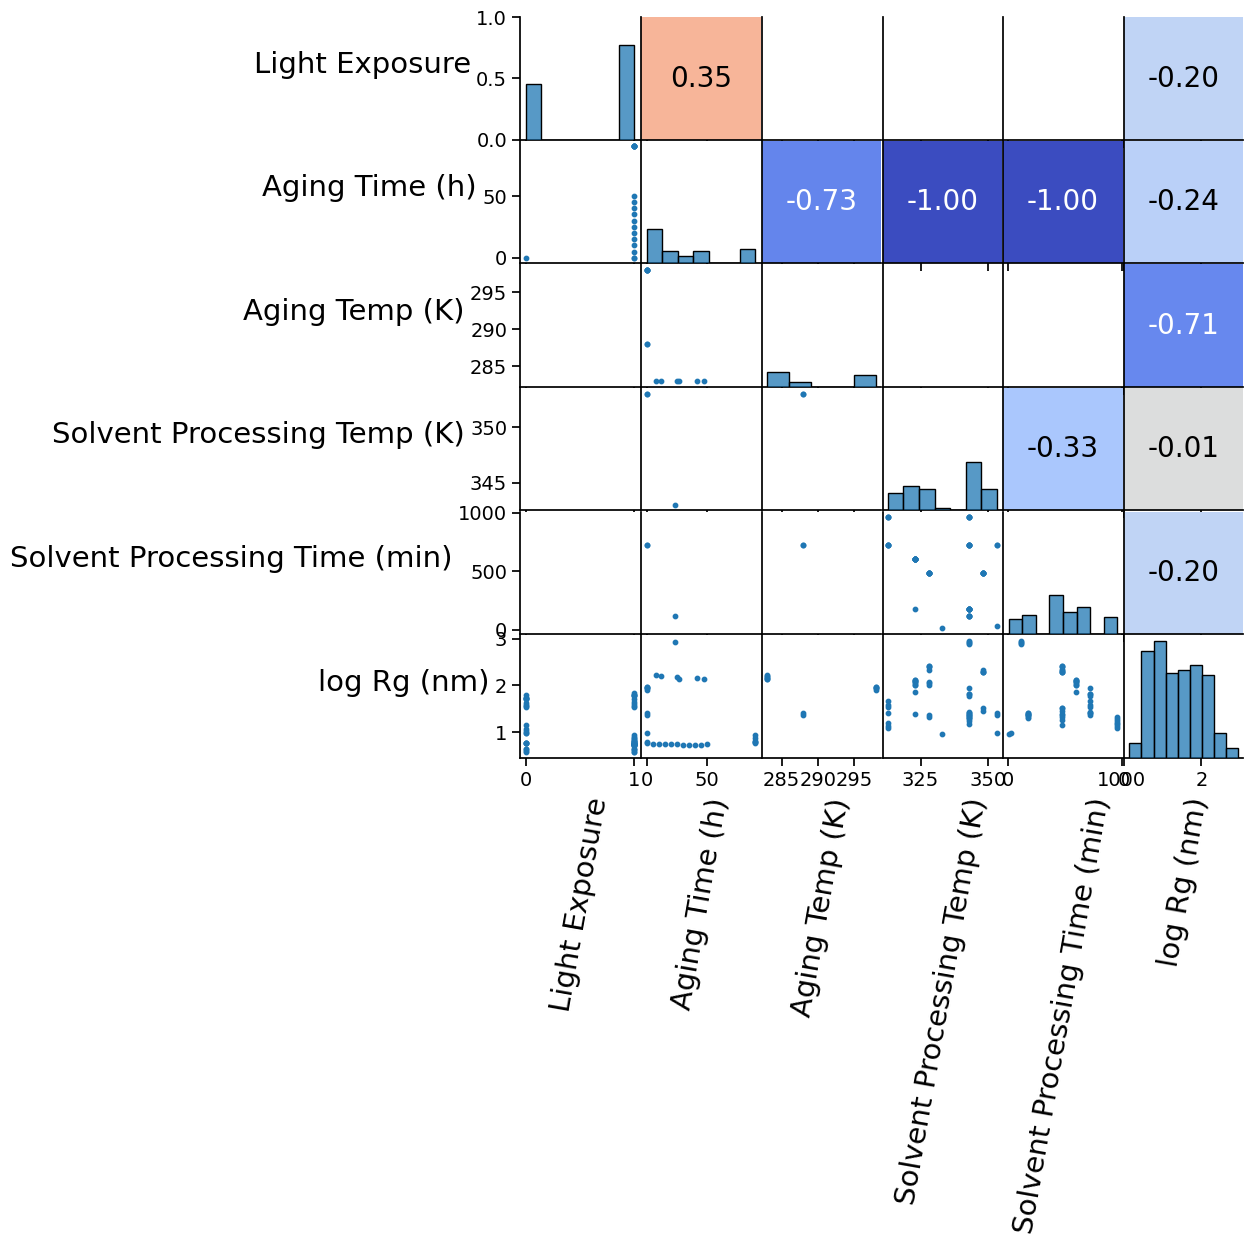

In [289]:
Rg_working_data_illustration_before_imputation =Rg_working_data.rename(columns={
    'Dark/light': 'Light Exposure',
    'Aging time (hour)': 'Aging Time (h)',
    'To Aging Temperature (K)': 'Aging Temp (K)',
    'Sonication/Stirring/heating Temperature (K)': 'Solvent Processing Temp (K)',
    'Merged Stirring /sonication/heating time(min)': 'Solvent Processing Time (min)'
})

varied_processing_parameters_illustration = [
  'Light Exposure',
  'Aging Time (h)',
  'Aging Temp (K)',
  'Solvent Processing Temp (K)',
  'Solvent Processing Time (min)',
  'log Rg (nm)'
              ]
draw_heat_pair_plot(df=Rg_working_data_illustration_before_imputation,parameters=varied_processing_parameters_illustration, title='',threshold=200,fig_size=(8, 8),fontsize=19)


In [290]:
Rg_working_data_imputed = Rg_with_cleaned_aging.copy()

In [291]:
columns_to_fill = {
    'Dark/light': 0,
    'Aging time (hour)': 0,
    'To Aging Temperature (K)': 298,
    'Sonication/Stirring/heating Temperature (K)': 298,
    'Merged Stirring /sonication/heating time(min)': 0
}

Rg_working_data_imputed[list(columns_to_fill.keys())] = (
    Rg_working_data_imputed[list(columns_to_fill.keys())]
    .fillna(value=columns_to_fill)
)

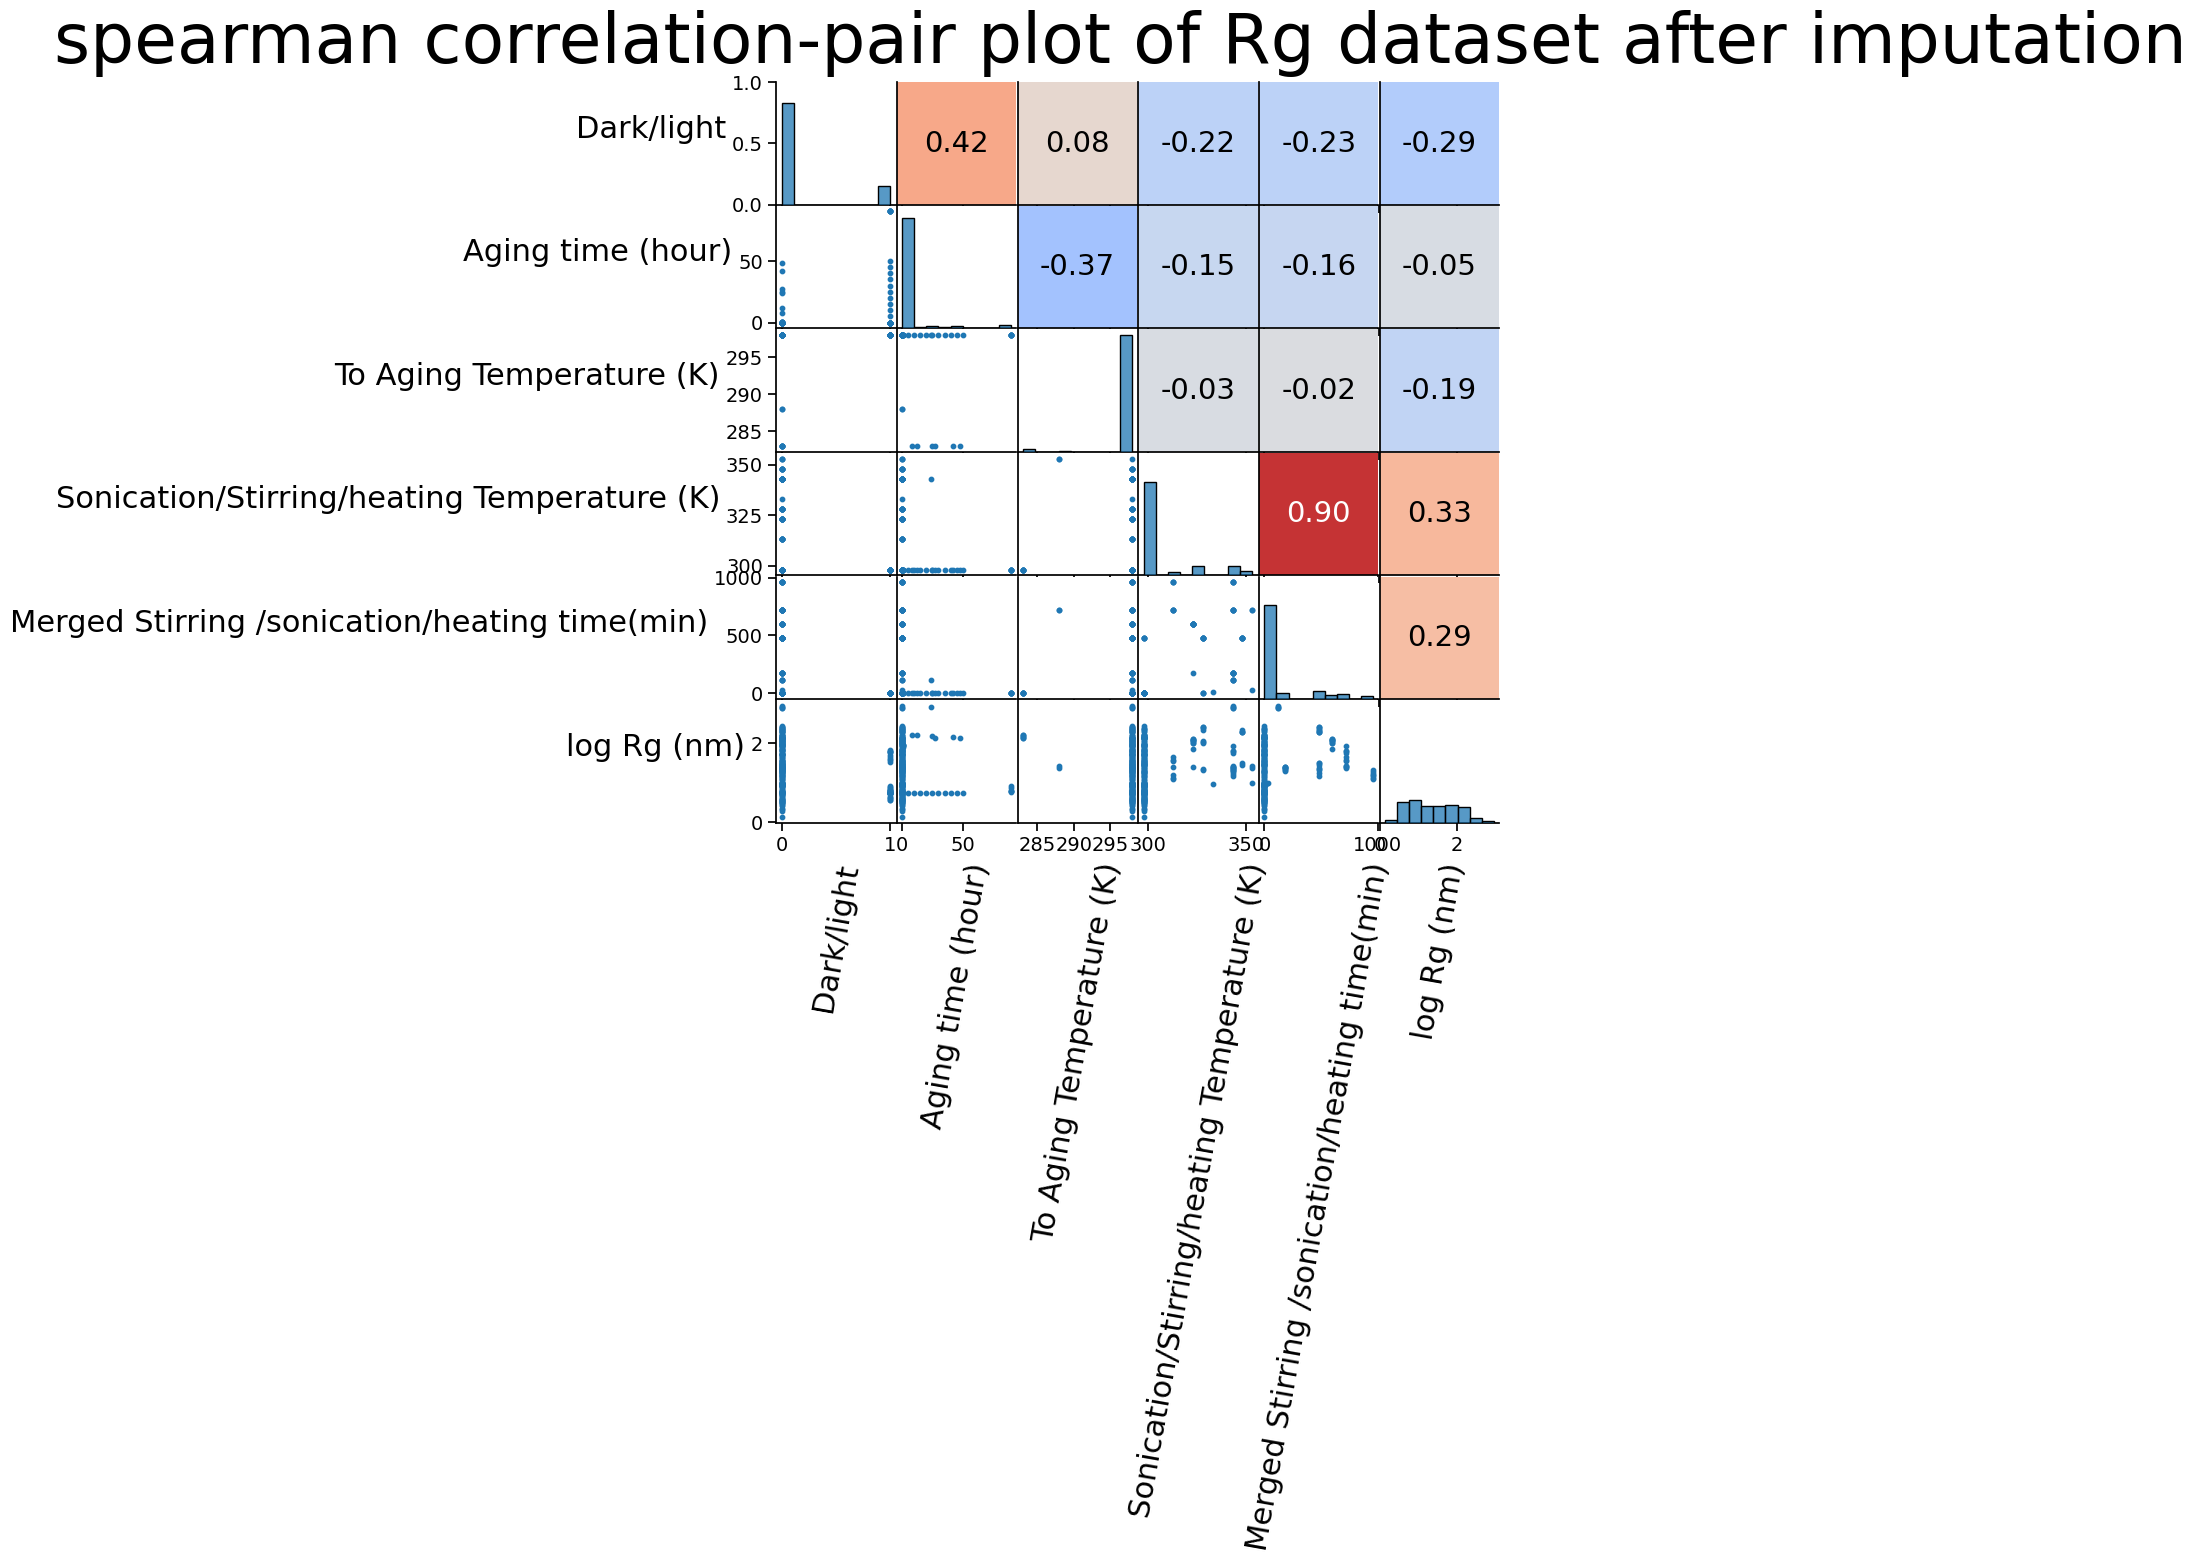

In [292]:
draw_heat_pair_plot(df=Rg_working_data_imputed,parameters=list(columns_to_fill.keys())+['log Rg (nm)'], title="spearman correlation-pair plot of Rg dataset after imputation",threshold=200,fig_size=(8, 8))


In [293]:
all+list(columns_to_fill.keys())+['log Rg (nm)']

['Xn',
 'Mw (g/mol)',
 'PDI',
 'polymer dP',
 'polymer dD',
 'polymer dH',
 'solvent dP',
 'solvent dD',
 'solvent dH',
 'Concentration (mg/ml)',
 'Temperature SANS/SLS/DLS/SEC (K)',
 'abs(solvent dD - polymer dD)',
 'abs(solvent dP - polymer dP)',
 'abs(solvent dH - polymer dH)',
 'Ra',
 'Dark/light',
 'Aging time (hour)',
 'To Aging Temperature (K)',
 'Sonication/Stirring/heating Temperature (K)',
 'Merged Stirring /sonication/heating time(min)',
 'log Rg (nm)']

In [294]:
Rg_working_data_imputed_illustration = Rg_working_data_imputed.rename(columns={
    'Dark/light': 'Light Exposure',
    'Aging time (hour)': 'Aging Time (h)',
    'To Aging Temperature (K)': 'Aging Temp (K)',
    'Sonication/Stirring/heating Temperature (K)': 'Solvent Processing Temp (K)',
    'Merged Stirring /sonication/heating time(min)': 'Solvent Processing Time (min)'
})

all_spaces = ['Xn',
  'Mw (g/mol)',
  'PDI',
  'polymer dP',
  'polymer dD',
  'polymer dH',
  'solvent dP',
  'solvent dD',
  'solvent dH',
  'Concentration (mg/ml)',
  'Temperature SANS/SLS/DLS/SEC (K)',
  'abs(solvent dD - polymer dD)',
  'abs(solvent dP - polymer dP)',
  'abs(solvent dH - polymer dH)',
  'Ra',
  'Light Exposure',
  'Aging Time (h)',
  'Aging Temp (K)',
  'Solvent Processing Temp (K)',
  'Solvent Processing Time (min)',
  'log Rg (nm)'
              ]

In [295]:
Rg_working_data_illustration_before_imputation.columns.to_list()

['name',
 'Mw (g/mol)',
 'Mn (g/mol)',
 'PDI',
 'Regioregularity R%',
 'DP',
 'SANS',
 'SAXS/GWAXS',
 'DLS',
 'SLS',
 'SEC (GPC)',
 'DLS Angle (deg)',
 'Concentration (mg/ml)',
 'Temperature SANS/SLS/DLS/SEC (K)',
 'Light Exposure',
 'Applied Electrical Field (Kv/cm)',
 'Duration of Applied Electrical Field (min)',
 'Aging Time (h)',
 'Aging Temp (K)',
 'Stirring /heating time(min)',
 'Sonication time (min)',
 'Solvent Processing Temp (K)',
 'storage temperature (K)',
 'Storage time (hour)',
 'Solvent(s)',
 'Deuterated solvent',
 'Solid additive',
 'Solid additive quantity (mg/ml)',
 'Rh1 (nm)',
 'I1 (Normalized 1-0)',
 'Rh2 (nm)',
 'I2 (Normalized 1-0)',
 'Rh3 (nm)',
 'I3 (Normalized 1-0)',
 'Rh4 (nm)',
 'I4 (Normalized 1-0)',
 'Rh deviation (nm) ±',
 'Rg1 (nm)',
 'Rg2 (nm)',
 'Rg 1deviation (nm) ±',
 'Rcs,g (crossectional radius) (nm)',
 'Rcs,g (crossectional radius) (nm) ±',
 'Rt,g (radius of gyration) (nm)',
 'Ree (chain end-to-end distance) (nm)',
 'Ree deviation (nm) ±',
 'A2 (mo

In [228]:
draw_heat_pair_plot(df=Rg_working_data_illustration_before_imputation,parameters=all+varied_processing_parameters_illustration, title='',threshold=100,fig_size=(20, 20),fontsize=23)

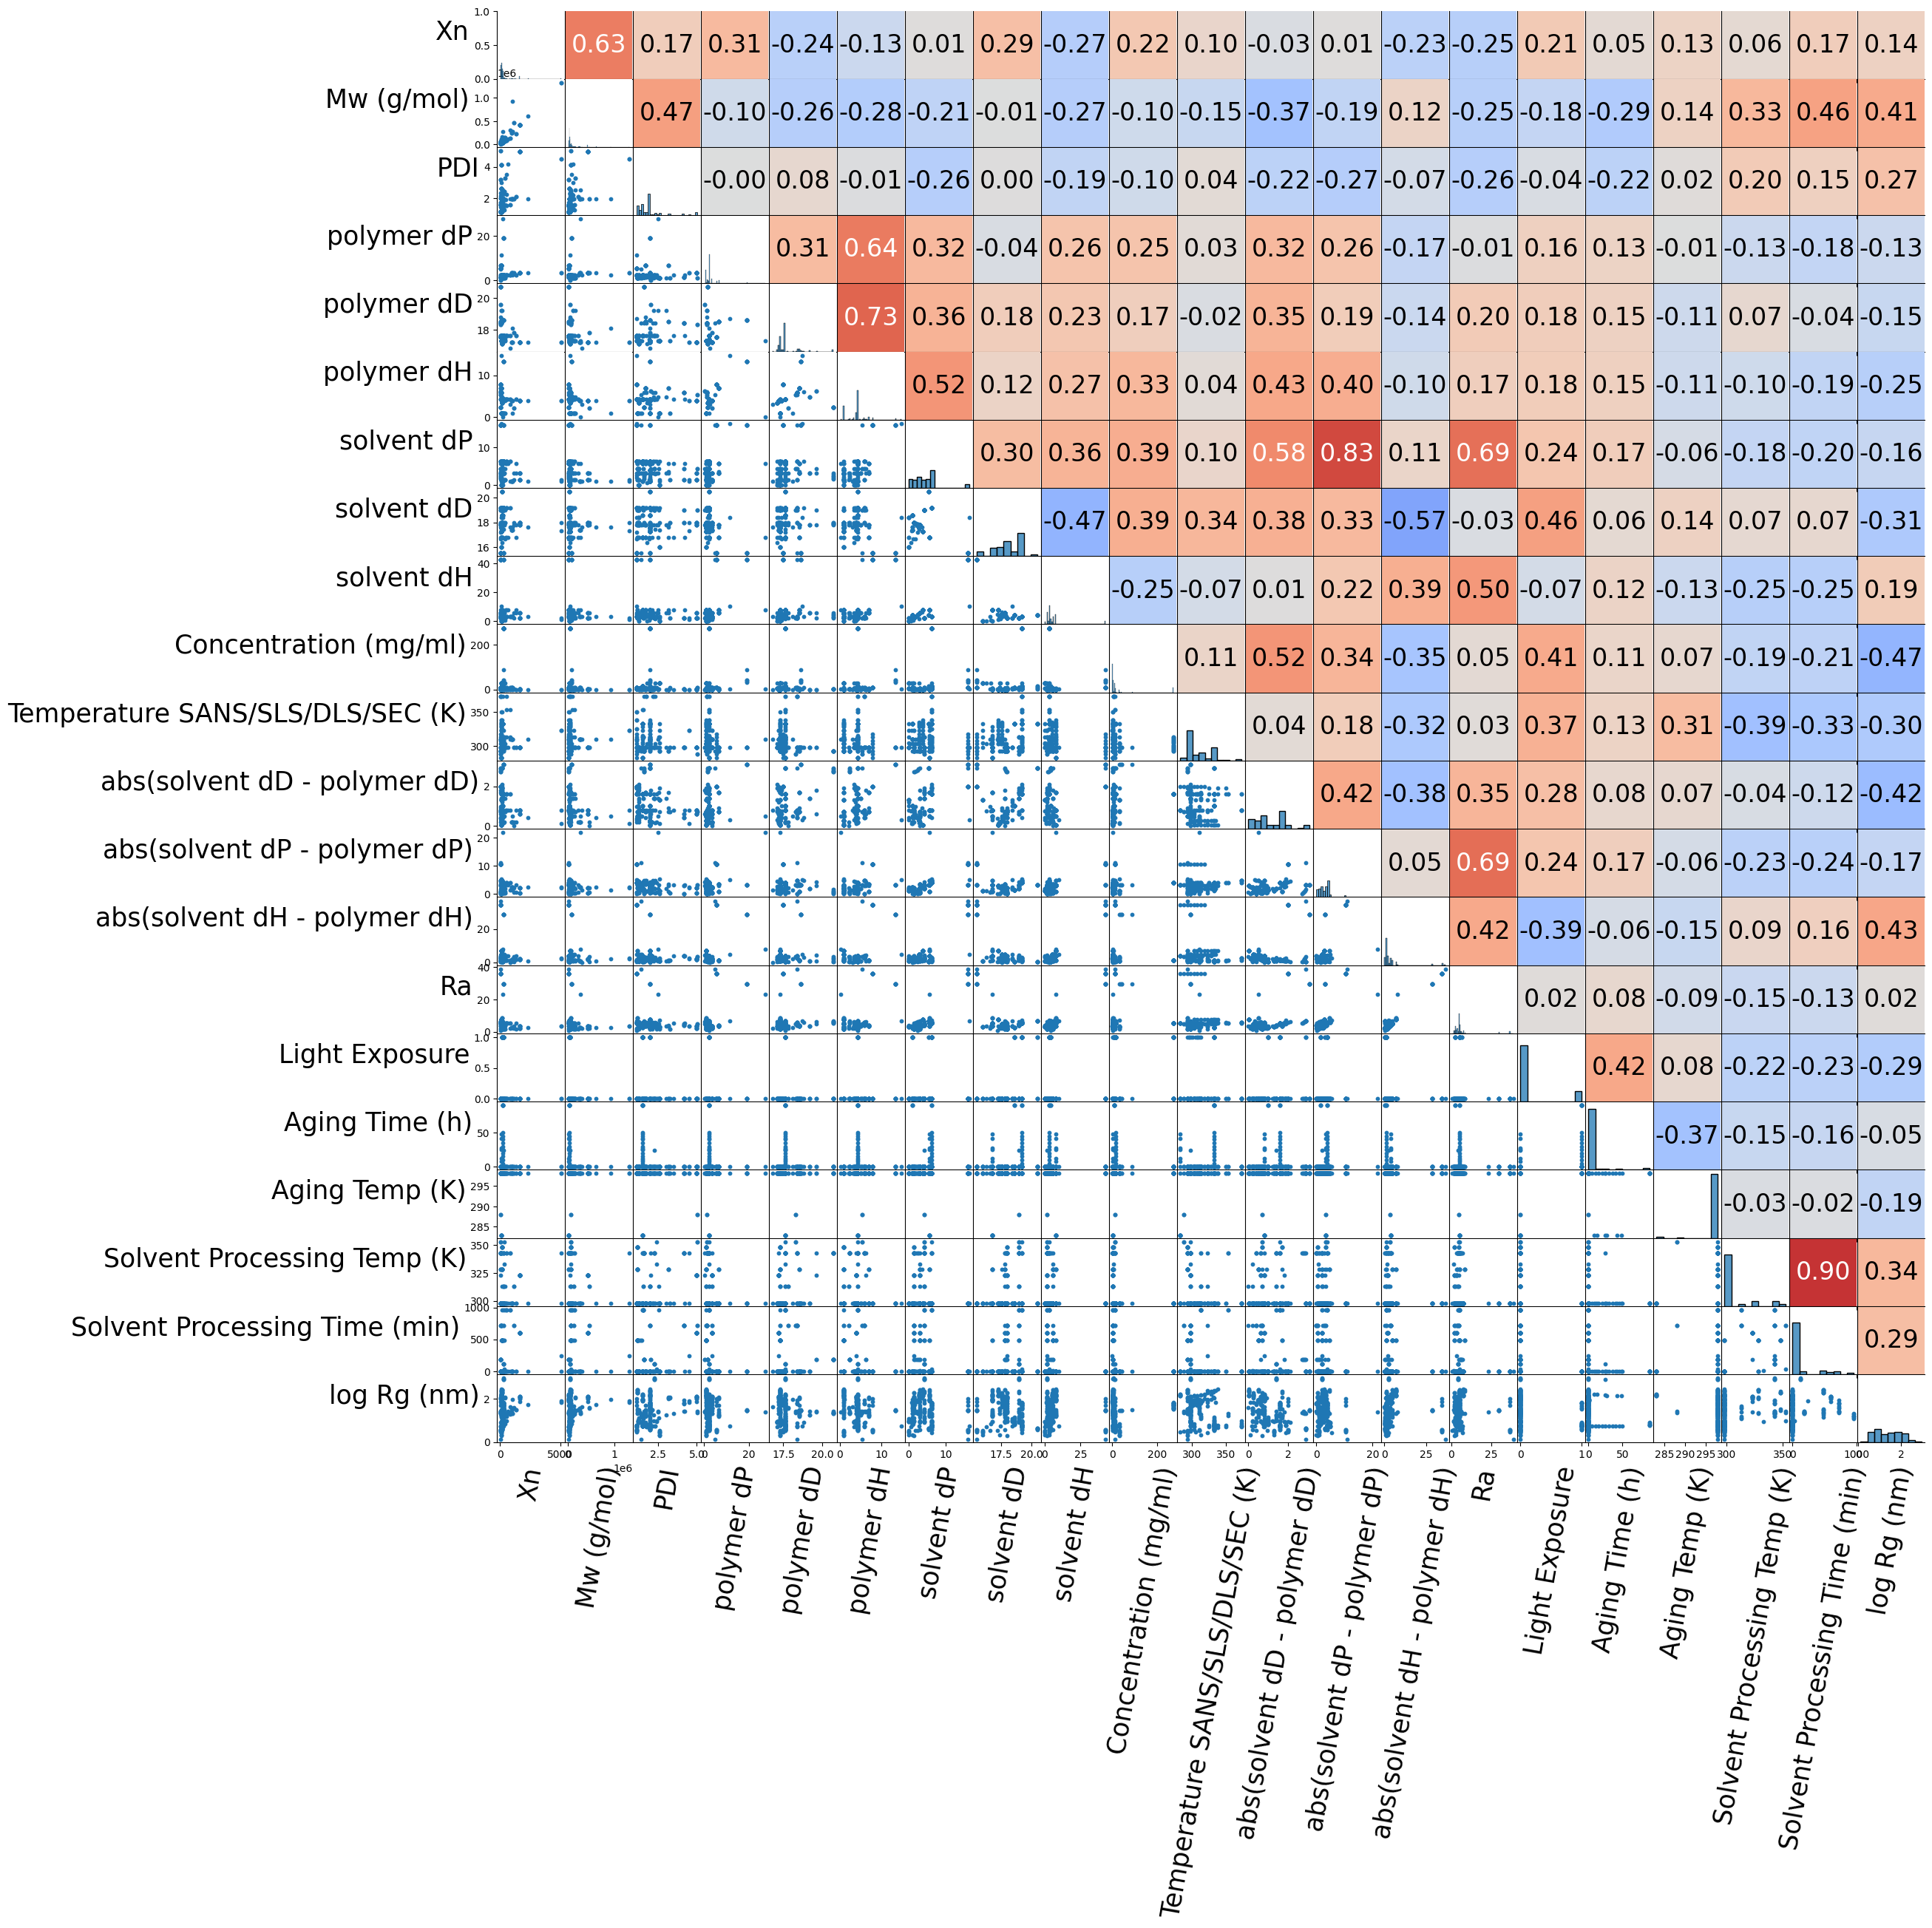

In [ ]:
draw_heat_pair_plot(df=Rg_working_data_imputed_illustration,parameters=all_spaces,
                    title="",threshold=100,fig_size=(20, 20),fontsize=23)


## extract files

In [296]:
Rg_working_data_imputed = Rg_working_data_imputed.reset_index(drop=True)
Rg_working_data_imputed.to_pickle(data_folder/'Rg data with aging imputed.pkl')

## distribution of values

In [ ]:
def distribution_plot(df: pd.DataFrame, parameters: List[str], log_cutoff: int = 200, columns_per_row: int = 2,
                      figsize=(16, 10.5), title: str = "Distribution Plots"
                      )->None:
    num_plots = len(parameters)
    num_rows = (num_plots - 1) // columns_per_row + 1
    fig, axes = plt.subplots(nrows=num_rows, ncols=columns_per_row, figsize=figsize)
    fig.suptitle(title, fontsize=30, fontweight='bold')
    if num_rows == 1:
        axes = axes.reshape(1, -1)

    for i, column in enumerate(parameters):
        row_idx = i // columns_per_row
        col_idx = i % columns_per_row

        # Determine the main plot
        data_range = df[column].max() - df[column].min()
        if data_range >= log_cutoff:
            data = np.log10(df[column])
            xlabel = f'log {column}'
        else:
            data = df[column]
            xlabel = column

        # Histogram plot
        sns.histplot(data, ax=axes[row_idx, col_idx], kde=False, color='#ACD4DC')

        axes[row_idx, col_idx].set_xlabel(xlabel, fontsize=20, fontweight='bold')
        axes[row_idx, col_idx].set_ylabel('occurrence ', fontsize=20, fontweight='bold')
        axes[row_idx, col_idx].tick_params(axis='both', labelsize=18)
        # Box plot as inset
        box_inset = axes[row_idx, col_idx].inset_axes([0.01, -0.5, 0.99, 0.2])  # Adjust position for the inset box plot
        sns.boxplot(x=data, ax=box_inset,color='#ACD4DC')
        box_inset.set(yticks=[], xlabel=None)  # Remove y-ticks and x-label from the box plot
        box_inset.tick_params(axis='x', labelsize=18)

    # Remove any unused subplots
    for j in range(i + 1, num_rows * columns_per_row):
        row_idx = j // columns_per_row
        col_idx = j % columns_per_row
        fig.delaxes(axes[row_idx, col_idx])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


In [ ]:
dist_features = ['Mw (g/mol)', 'Concentration (mg/ml)', 'Temperature SANS/SLS/DLS/SEC (K)', 'Ra']
rg_features = dist_features
rh_features = dist_features + ['log Rh (nm)']
lp_features = dist_features + ['Lp (nm)']



In [ ]:
selected_for_paper= [
  'Rg (nm)',
  'Mw (g/mol)',
  'polymer dP',
  'polymer dD',
  'polymer dH',
  'solvent dP',
  'solvent dD',
  'solvent dH',
  'Temperature SANS/SLS/DLS/SEC (K)',
  'abs(solvent dD - polymer dD)',
  'abs(solvent dP - polymer dP)',
  'abs(solvent dH - polymer dH)',
  'Ra',
  'Light Exposure',
  'Aging Time (h)',
  'Aging Temp (K)',
  'Solvent Processing Temp (K)',
  'Solvent Processing Time (min)',
]

In [ ]:
Rg_working_data_imputed_illustration['Rg (nm)']=Rg_working_data_imputed_illustration['Rg1 (nm)'].copy()

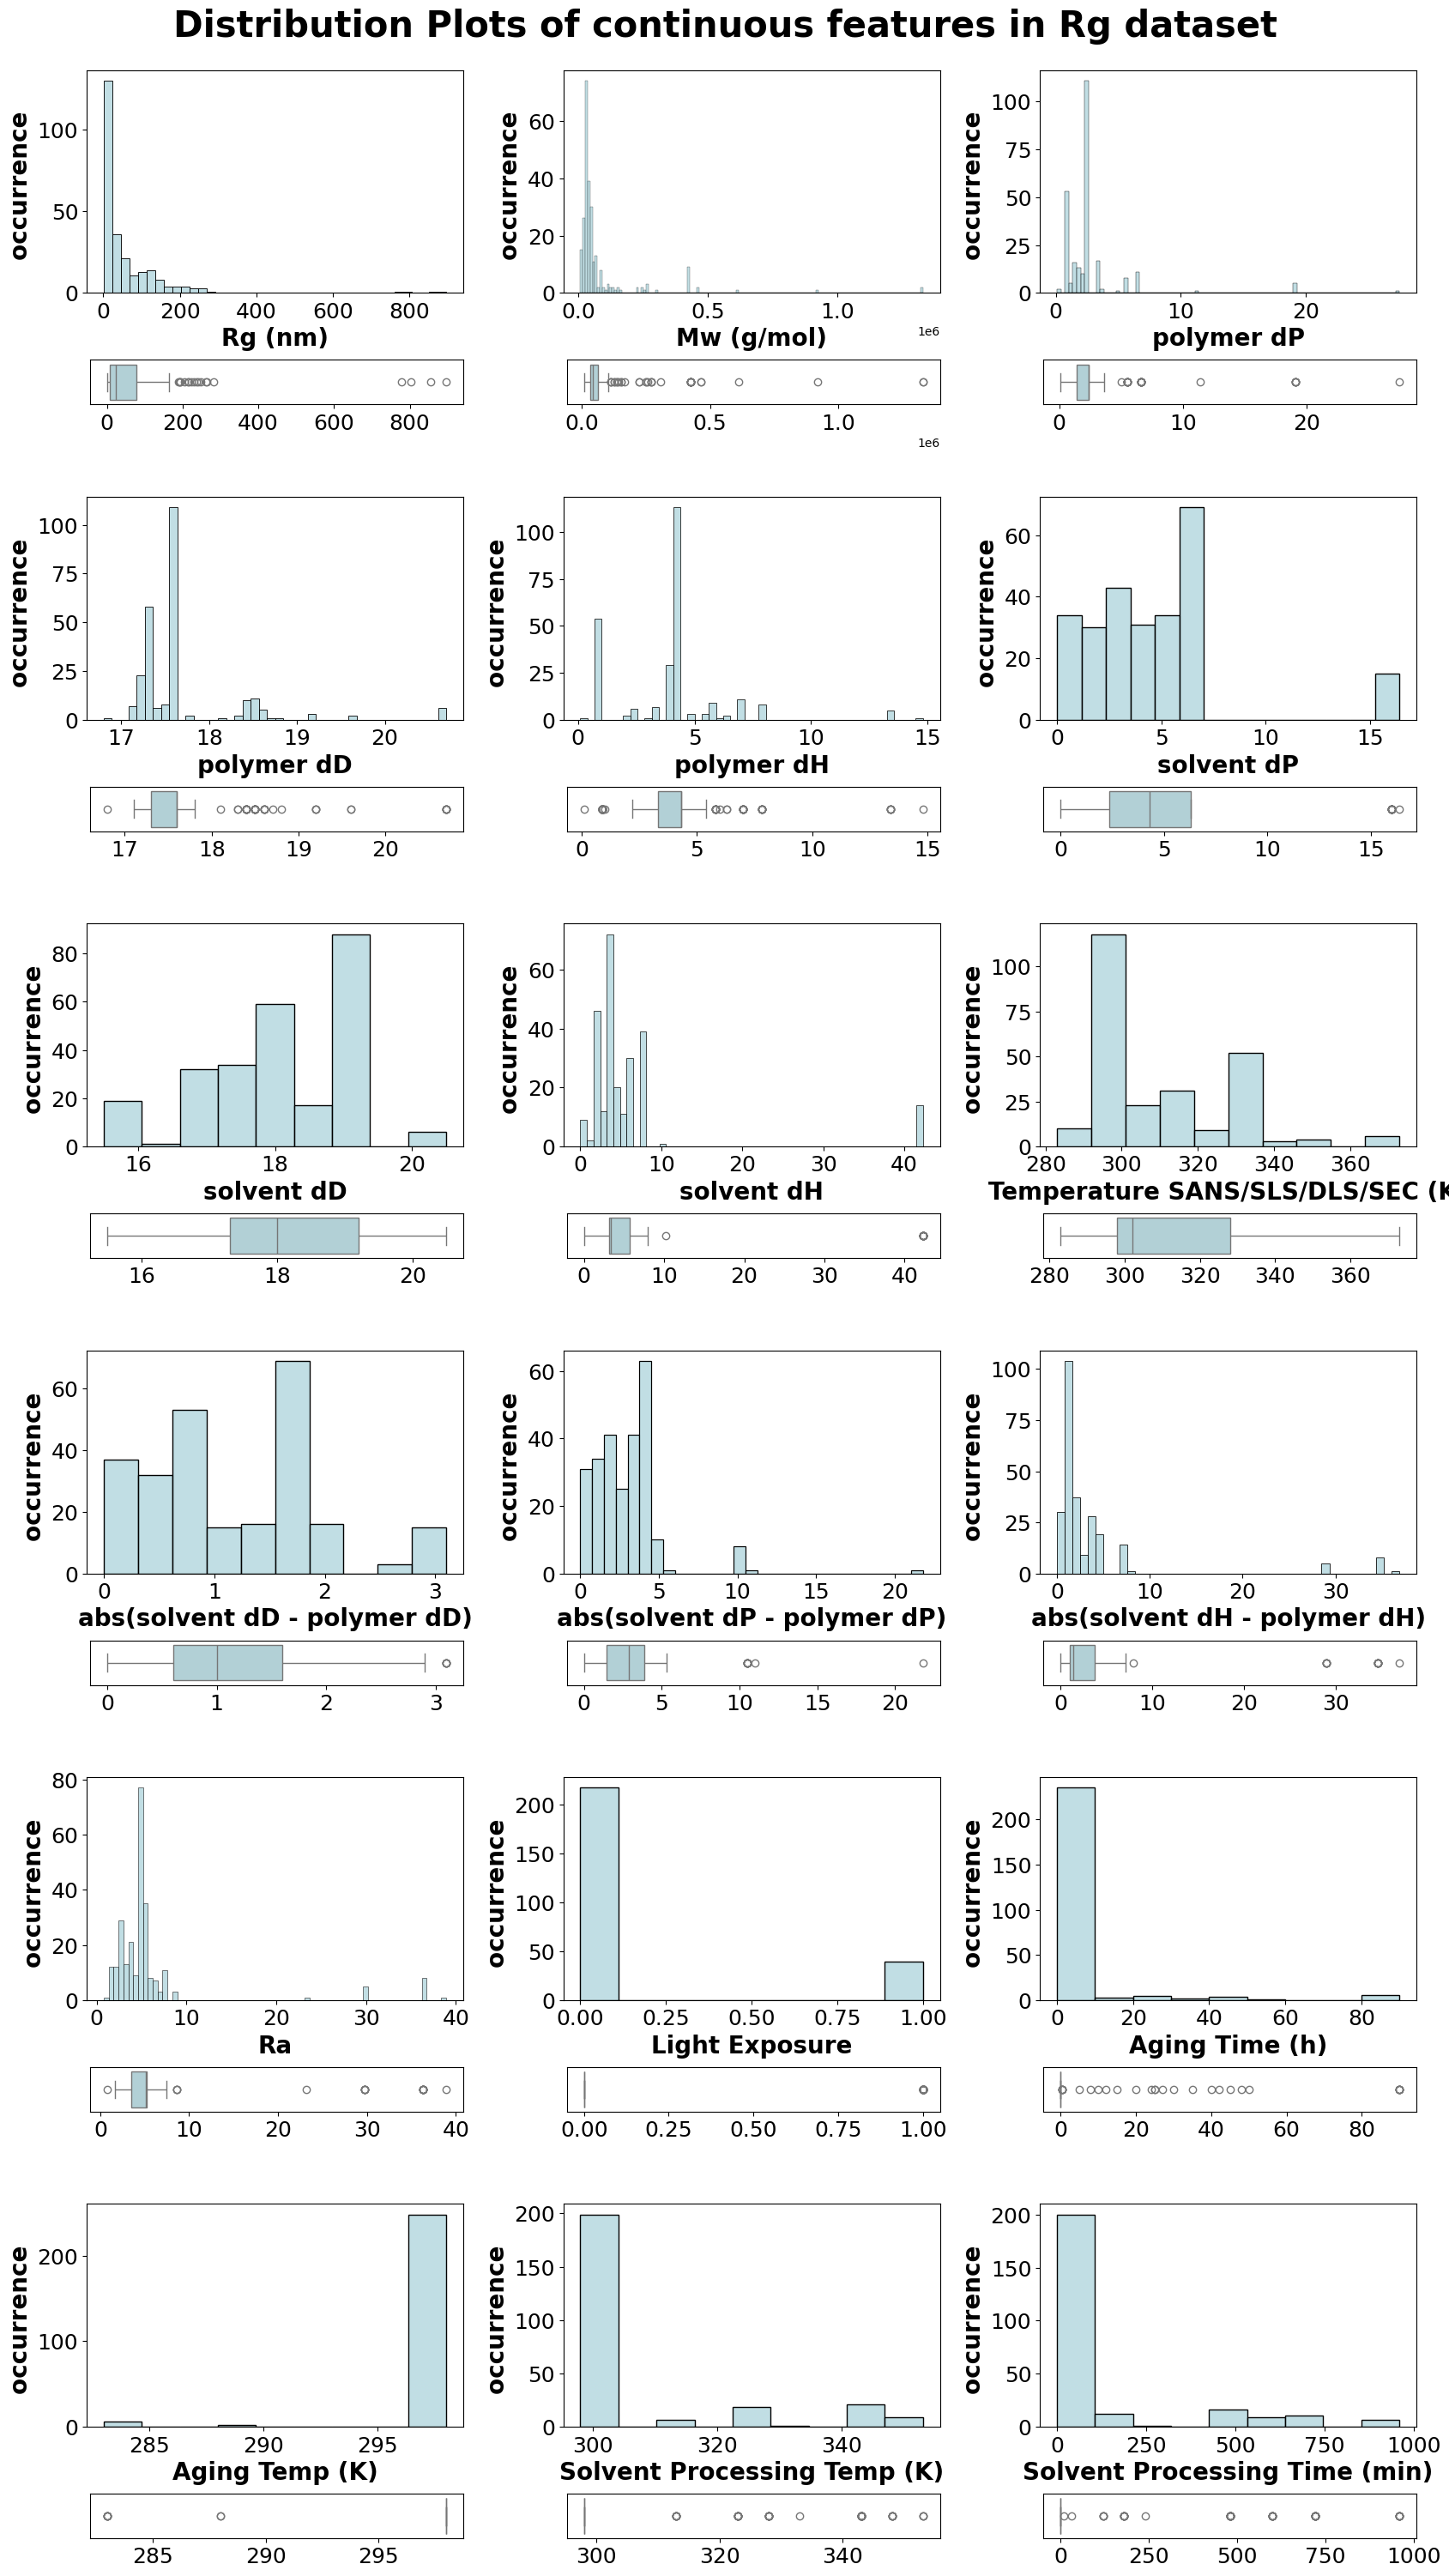

In [ ]:
# Rg dataset
distribution_plot(df=Rg_working_data_imputed_illustration, parameters=selected_for_paper, columns_per_row=3, log_cutoff=10000000,figsize=(17,31),title = "Distribution Plots of continuous features in Rg dataset")

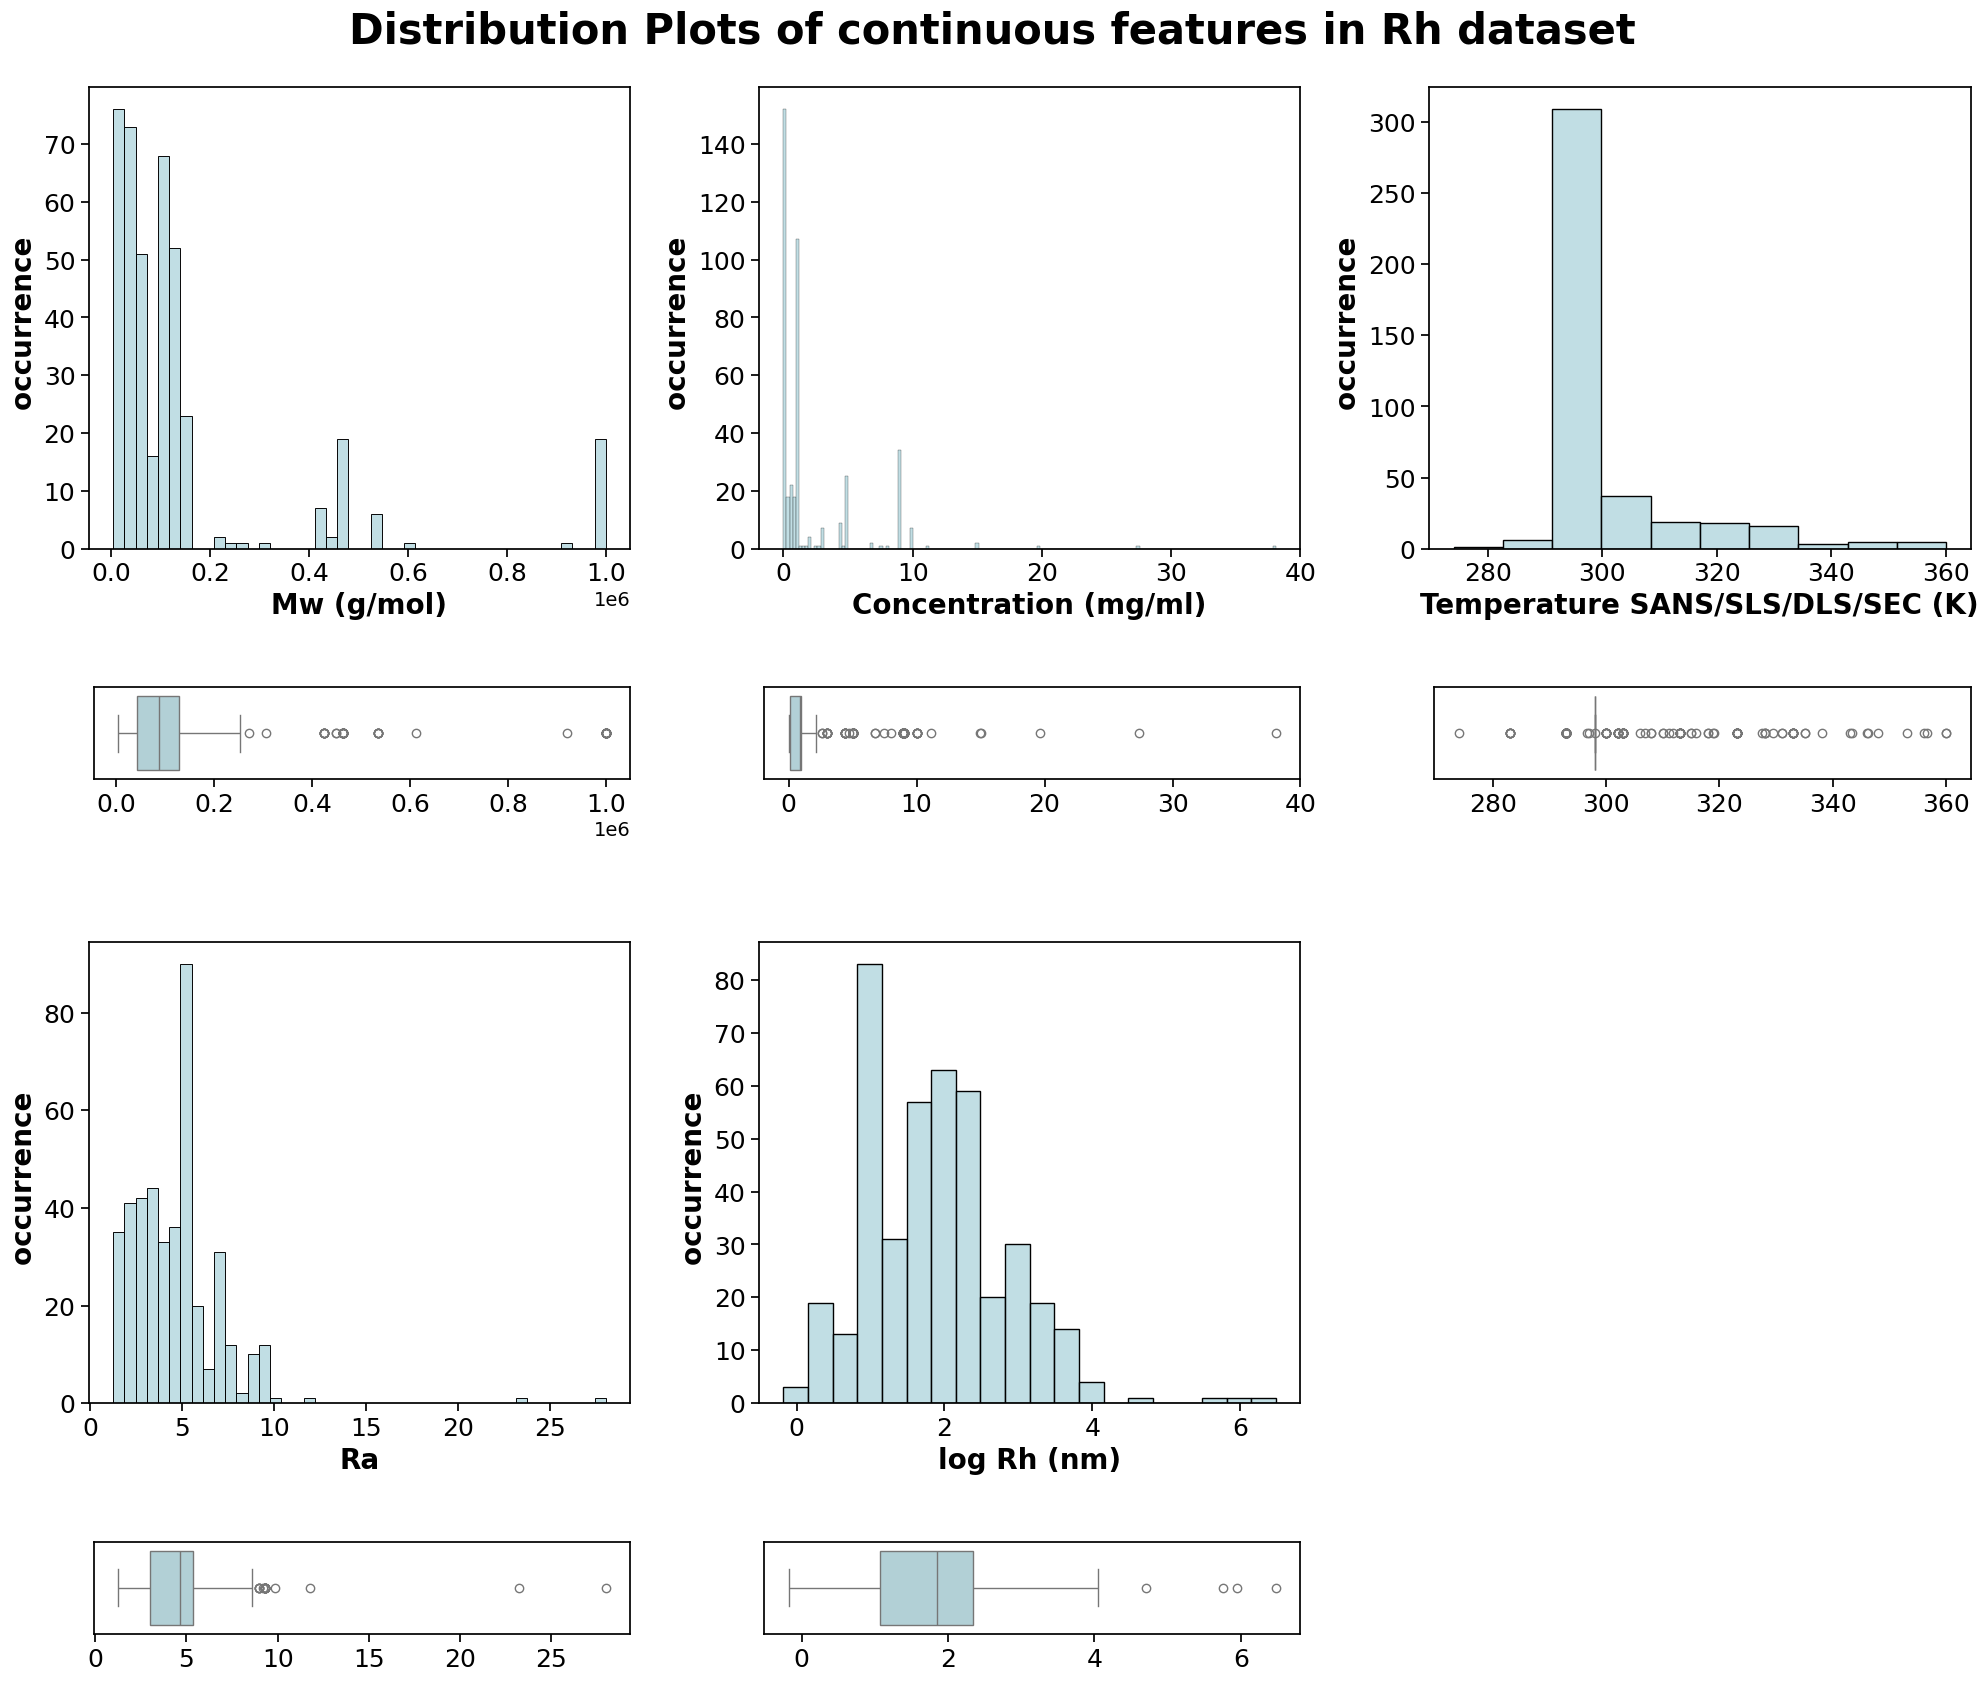

In [ ]:
# Rh dataset
distribution_plot(df=imputed_Rh_data, parameters=rh_features, columns_per_row=3, log_cutoff=10000000,figsize=(20,18),title = "Distribution Plots of continuous features in Rh dataset")

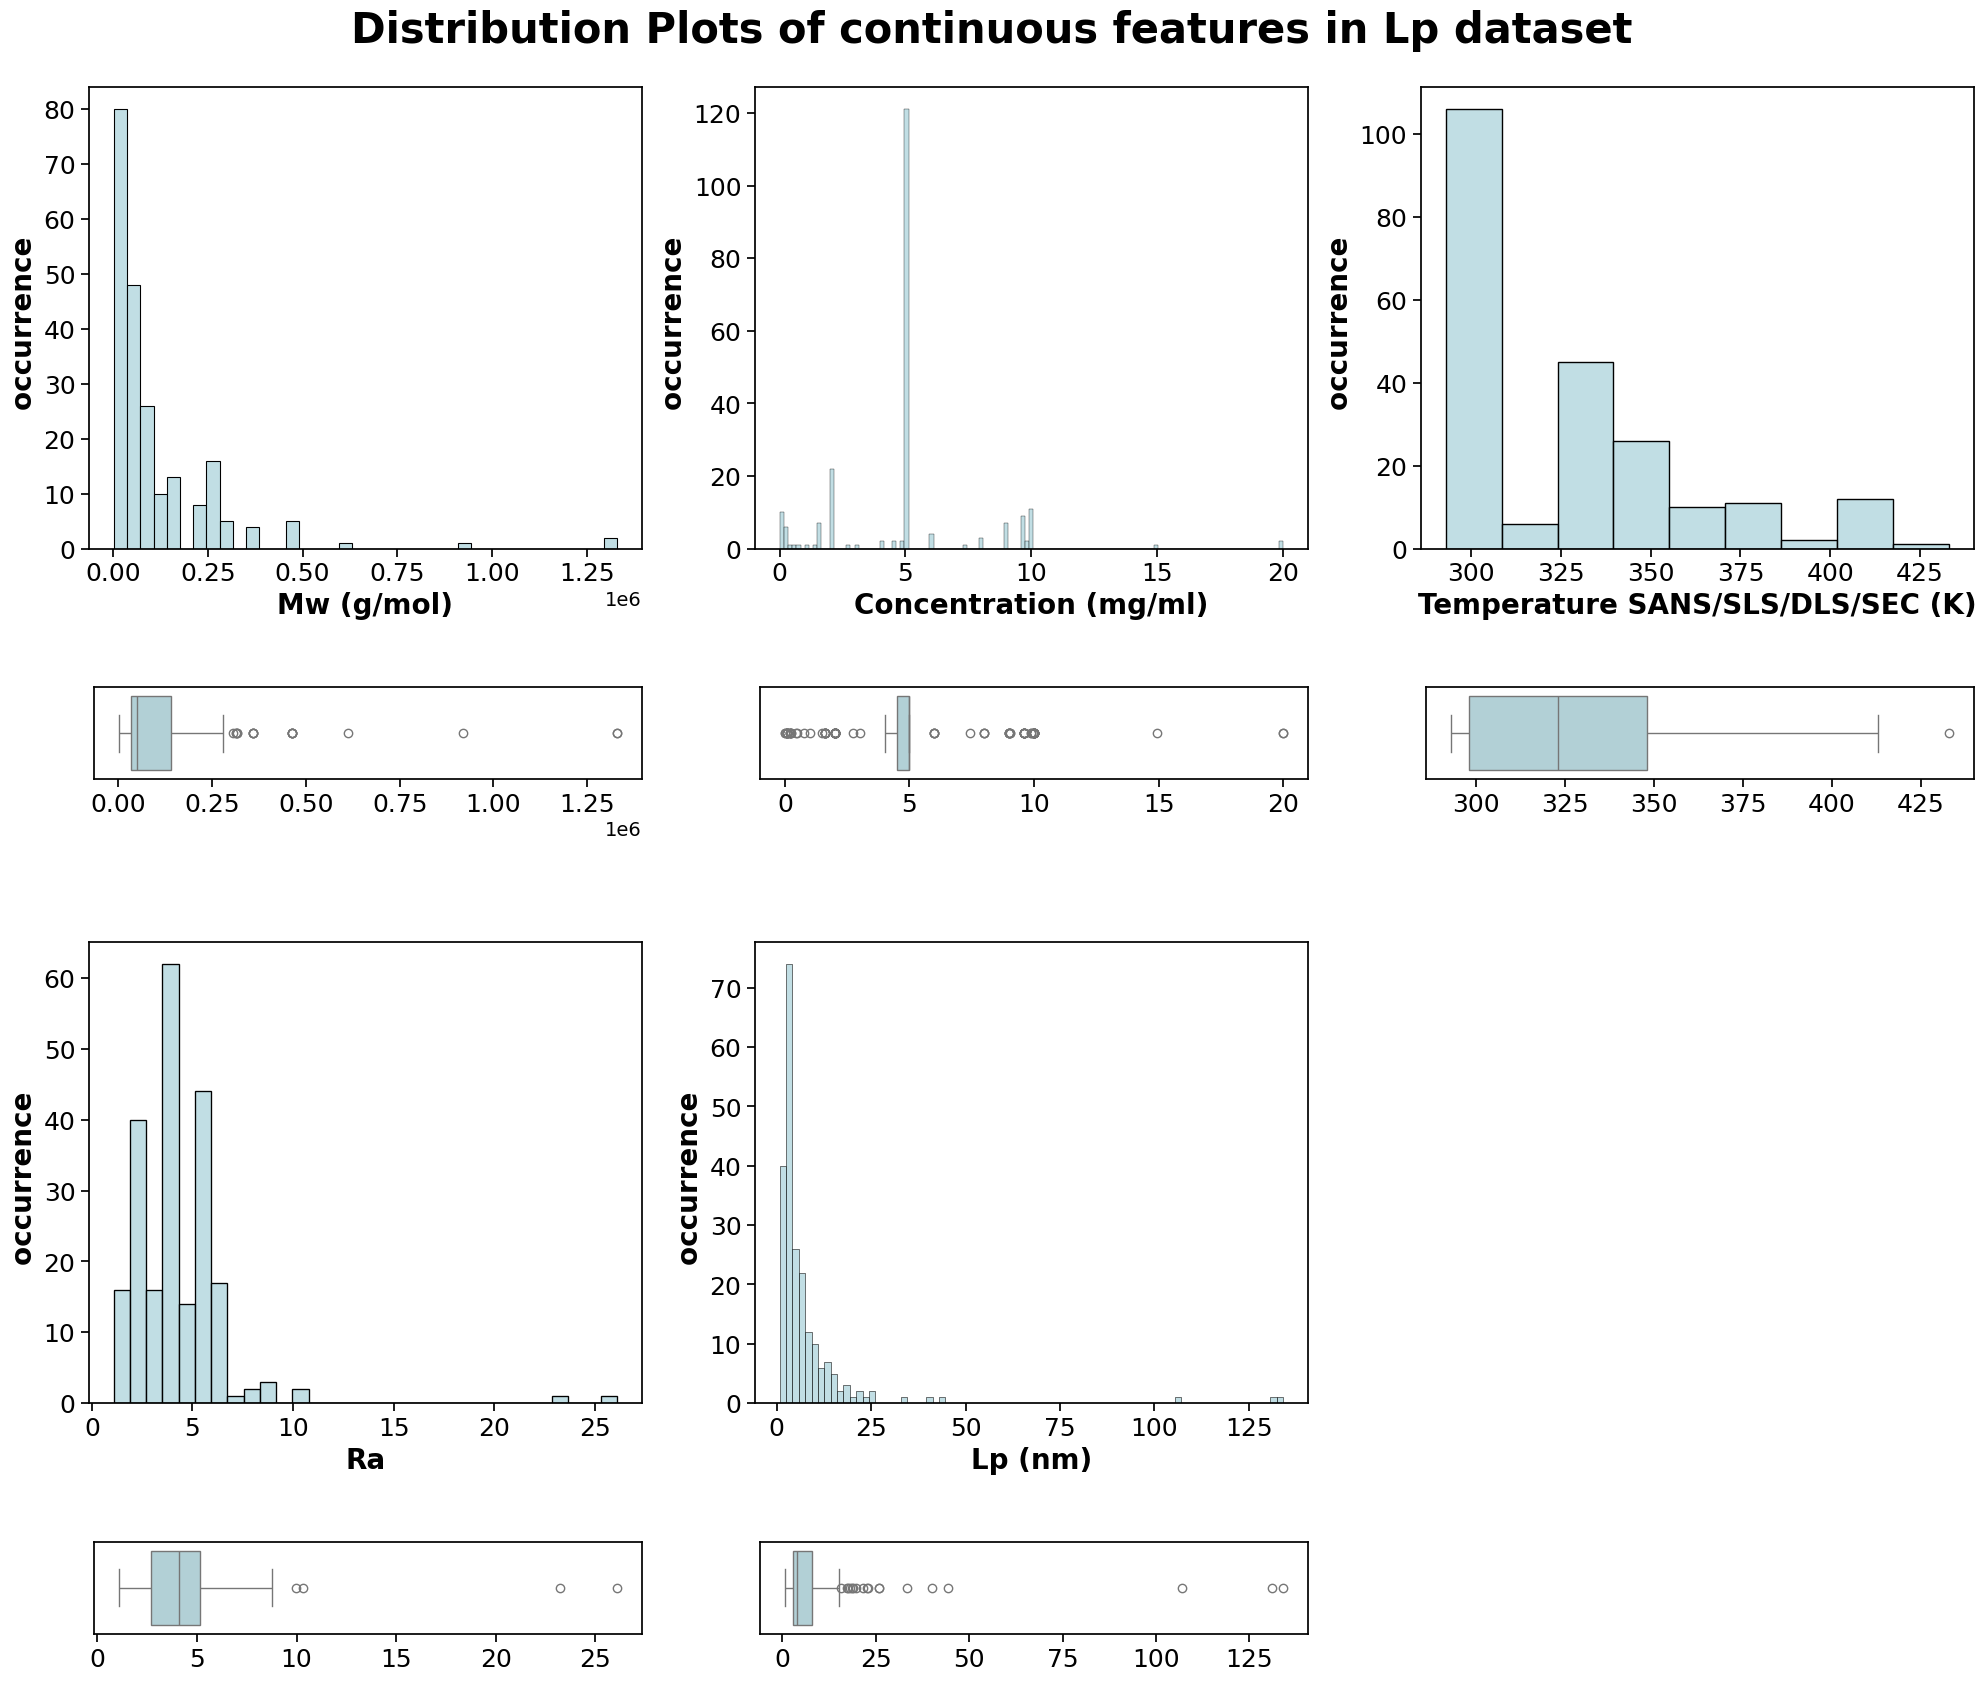

In [ ]:
# Lp dataset
distribution_plot(df=imputed_Lp_data, parameters=lp_features, columns_per_row=3, log_cutoff=10000000,figsize=(20,18),title = "Distribution Plots of continuous features in Lp dataset")

## Rg and conformation evaluation

In [ ]:
Rg_working_data_imputed_illustration: pd.DataFrame = pd.read_pickle(data_folder/'Rg data with aging imputed.pkl')

In [ ]:
Rg_working_data_imputed_illustration

,name,Mw (g/mol),Mn (g/mol),PDI,Regioregularity R%,DP,SANS,SAXS/GWAXS,DLS,SLS,...,polymer dD,solvent dH,polymer dH,Ra,abs(solvent dD - polymer dD),abs(solvent dP - polymer dP),abs(solvent dH - polymer dH),log Rg (nm),Merged Stirring /sonication/heating time(min),Xn
0,MEH-PPV,611000.0,NaN,1.965375,NaN,2350,0,0,1.0,1,...,17.2,3.100,4.0,2.774887,0.400,2.500,0.900,1.719331,0.0,2346.597434
1,BEH-PPV,306000.0,NaN,1.965375,NaN,854,0,0,1.0,1,...,16.8,3.100,3.1,2.193171,0.800,1.500,0.000,1.624282,0.0,853.399374
2,BCHA-PPV,920000.0,NaN,1.965375,NaN,1055,0,0,1.0,1,...,18.1,3.100,1.0,2.714774,0.500,1.400,2.100,1.964260,0.0,1018.242027
3,PFO,46000.0,NaN,1.965375,NaN,NaN,0,0,1.0,1,...,17.3,2.522,0.9,2.150719,0.634,0.622,1.622,1.721151,0.0,118.361770
4,PFO,46000.0,NaN,1.965375,NaN,NaN,0,0,1.0,1,...,17.3,3.044,0.9,2.568962,0.568,0.844,2.144,1.822560,0.0,118.361770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,P3HT,24000.0,16000.0,1.500000,NaN,NaN,0,0,1.0,1,...,17.6,8.000,4.3,5.209607,0.800,3.300,3.700,1.895975,0.0,144.327045
252,P3HT,24000.0,16000.0,1.500000,NaN,NaN,0,0,1.0,1,...,17.6,8.000,4.3,5.209607,0.800,3.300,3.700,1.948413,0.0,144.327045
253,P3HT,24000.0,16000.0,1.500000,NaN,NaN,0,0,1.0,1,...,17.6,8.000,4.3,5.209607,0.800,3.300,3.700,1.943495,0.0,144.327045
254,P3HT,24000.0,16000.0,1.500000,NaN,NaN,0,0,1.0,1,...,17.6,8.000,4.3,5.209607,0.800,3.300,3.700,1.962369,0.0,144.327045


0.14090891228260302


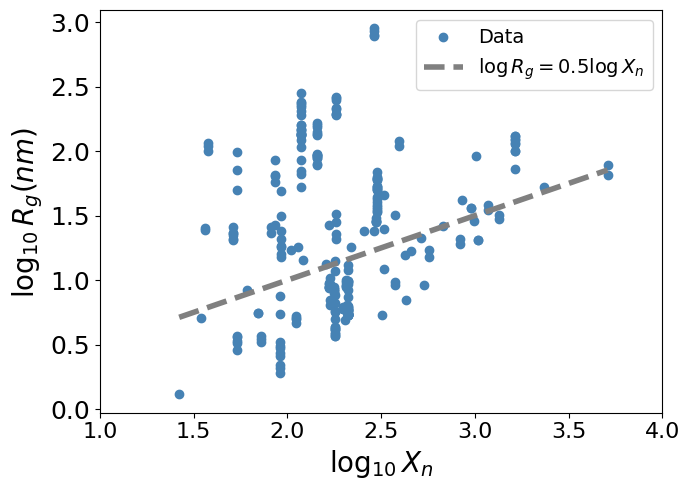

In [ ]:
DP = Rg_working_data_imputed_illustration['Xn'].values
log_DP = np.log10(DP)  # Compute log10(DP) directly
log_Rg = Rg_working_data_imputed_illustration['log Rg (nm)'].values  # Experimental log Rg
Rg = Rg_working_data_imputed_illustration['Rg1 (nm)'].values
# Generate smooth DP values for the theoretical curve
DP_fine = np.logspace(np.log10(min(DP)), np.log10(max(DP)), 100)  # Corrected logspace
log_DP_fine = np.log10(DP_fine)  # Log-transformed DP values
log_Rg_theory = 0.5 * log_DP_fine  # Theoretical log Rg = 0.5 * log DP

spearman_corr, _ = spearmanr(Rg, DP)
print(spearman_corr)
plt.figure(figsize=(7, 5))
plt.scatter(log_DP, log_Rg, color='#4682B4', label='Data')  # Scatter plot of experimental data
plt.plot(log_DP_fine, log_Rg_theory, color='grey', linestyle='--',linewidth=4,label=r'$\log R_g = 0.5 \log X_n$')  # Theoretical line

# Labels and formatting
plt.xlabel(r'$\log_{10} X_n$', fontsize=20,fontweight='bold')
plt.ylabel(r'$\log_{10} R_g (nm)$ ', fontsize=20,fontweight='bold')
plt.legend(fontsize=14)
plt.xlim(1,4)
plt.xticks(fontsize=16)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

def plot_polymer_regression(data, polymers, color='#E16363'):
    filtered_data = data[data['canonical_name'].isin(polymers)]
    Xn = filtered_data['Xn'].values
    log_Rg = filtered_data['log Rg (nm)'].values
    X = Xn.reshape(-1, 1)
    y = log_Rg
    lin_reg = LinearRegression().fit(X, y)
    y_pred = lin_reg.predict(X)

    r2_reg = r2_score(y, y_pred)
    rmse_reg = np.sqrt(mean_squared_error(y, y_pred))
    print(f"Linear Regression: R² = {r2_reg:.4f}, RMSE = {rmse_reg:.4f}")

    X_fine = np.linspace(min(Xn), max(Xn), 200).reshape(-1, 1)
    y_fit = lin_reg.predict(X_fine)

    plt.figure(figsize=(6, 5))
    plt.scatter(Xn, log_Rg, color=color, label=polymers[0])
    plt.plot(X_fine, y_fit, color='grey', linestyle='--', linewidth=4, label='Linear Regression')
    plt.xlabel(r'$X_n$', fontsize=20, fontweight='bold')
    plt.ylabel(r'$\log_{10} R_g \, (nm)$', fontsize=20, fontweight='bold')
    plt.legend(fontsize=14)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=18)
    plt.ylim(0,3)

    plt.tight_layout()
    plt.show()

Linear Regression: R² = 0.0183, RMSE = 0.5919


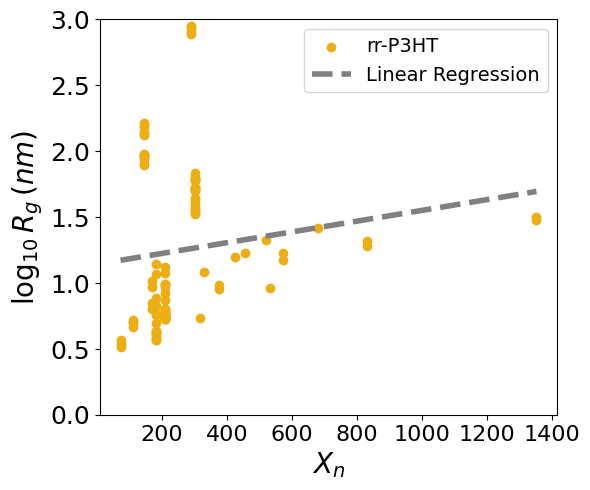

In [ ]:
plot_polymer_regression(Rg_working_data_imputed_illustration, ['rr-P3HT'], color='#ECAE12')


Linear Regression: R² = 0.0180, RMSE = 0.6656


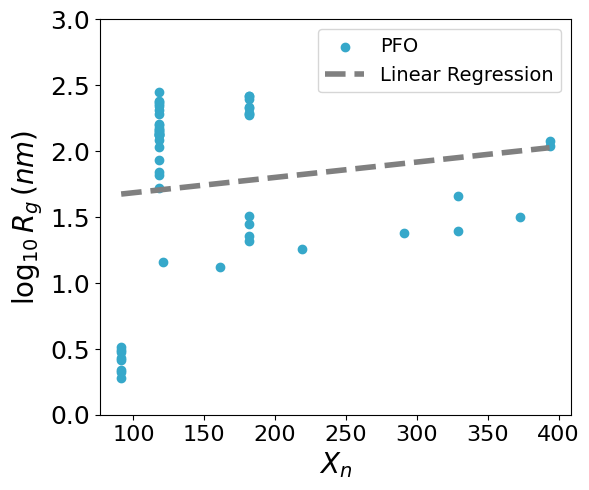

In [ ]:
plot_polymer_regression(Rg_working_data_imputed_illustration, ['PFO'], color='#36A8CA')


# Distribution Analysis

In [ ]:
from matplotlib.ticker import MaxNLocator

def plot_hanson_space(df, hsp_material:str):

    dP = df[f"{hsp_material} dP"]
    dD = df[f"{hsp_material} dD"]
    dH = df[f"{hsp_material} dH"]

    dP_freq = dP.map(dP.value_counts())
    # dD_freq = dD.map(dD.value_counts())
    # dH_freq = dH.map(dH.value_counts())

    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    maxlocator = {
        "integer":True,
        "prune":"lower",
        "nbins":6,
                  }

    sc = axes[0].scatter(dP, dD, c=dP_freq, cmap="viridis",edgecolors='none')
    axes[0].set_xlabel(r'$\delta P$ (MPa$^{1/2}$)')
    axes[0].set_ylabel(r'$\delta D$ (MPa$^{1/2}$)')
    axes[0].xaxis.set_major_locator(MaxNLocator(**maxlocator))
    axes[0].yaxis.set_major_locator(MaxNLocator(**maxlocator))

    # Scatter plot for dP vs dH
    sc = axes[1].scatter(dP, dH, c=dP_freq, cmap="viridis",edgecolors='none')
    axes[1].set_xlabel(r'$\delta P$ (MPa$^{1/2}$)')
    axes[1].set_ylabel(r'$\delta H$ (MPa$^{1/2}$)')
    axes[1].xaxis.set_major_locator(MaxNLocator(**maxlocator))
    axes[1].yaxis.set_major_locator(MaxNLocator(**maxlocator))

    # Scatter plot for dD vs dH
    sc = axes[2].scatter(dD, dH, c=dP_freq, cmap='viridis',edgecolors='none')
    axes[2].set_xlabel(r'$\delta D$ (MPa$^{1/2}$)')
    axes[2].set_ylabel(r'$\delta H$ (MPa$^{1/2}$)')
    axes[2].xaxis.set_major_locator(MaxNLocator(**maxlocator))
    axes[2].yaxis.set_major_locator(MaxNLocator(**maxlocator))
    cbar3 = fig.colorbar(sc, ax=axes[2], orientation="vertical", shrink=0.9, aspect=20)
    cbar3.set_label("Frequency")
    max_freq = dP_freq.max()
    cbar3.set_ticks(np.arange(0, max_freq , 25))  # <-- set 3 ticks
    fig.suptitle(f"{hsp_material.capitalize()} Hansen Solubility Parameters", fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()


In [ ]:
# exclude_polymers = ["P3OET", "MBL-PPV", "PTHS", "P3ImiHT"]

# Rg_working_data_imputed_illustration_ex = Rg_working_data_imputed_illustration[
#     ~Rg_working_data_imputed_illustration['canonical_name'].isin(exclude_polymers)
# ]

In [ ]:
# high_dD_rows = Rg_working_data_imputed_illustration_ex[Rg_working_data_imputed_illustration_ex["polymer dP"] > 20]
# hsp_material = 'polymer'
# high_dD_rows[[f"{hsp_material} dP",f"{hsp_material} dD",f"{hsp_material} dH",'canonical_name']]


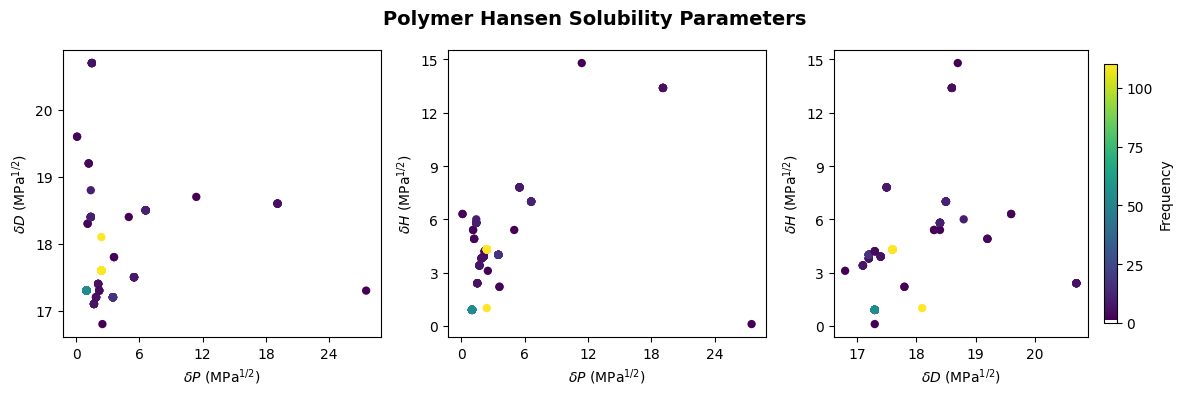

In [ ]:
plot_hanson_space(Rg_working_data_imputed_illustration, 'polymer')

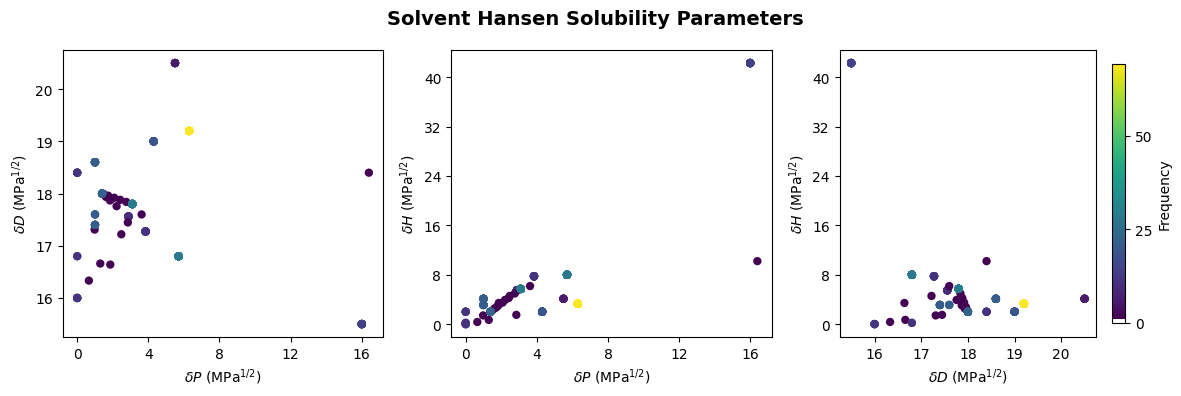

In [ ]:
plot_hanson_space(Rg_working_data_imputed_illustration, 'solvent')

In [ ]:
def plot_rg_vs_polymer(data, target:str,font_size=14, fig_size=(10, 6)):
    """
    Creates a combined violin and swarm plot of log Rg (nm) values for each polymer in canonical_name.

    Parameters:
    - data (pd.DataFrame): Must contain 'canonical_name' and 'log Rg (nm)' columns.
    - font_size (int): Font size for labels and ticks.
    - fig_size (tuple): Size of the figure.

    Returns:
    - None: Displays the plot.
    """
    plt.figure(figsize=fig_size)

    # Violin plot
    sns.violinplot(
        data=data,
        x='canonical_name',
        y=target,
        inner=None,
        palette='Set2',
        # linewidth=1
    )

    # Swarm plot overlaid
    sns.swarmplot(
        data=data,
        x='canonical_name',
        y=target,
        color='k',
        alpha=0.7,
        size=5
    )

    plt.xticks(rotation=45, ha='right', fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.xlabel('Polymer', fontsize=font_size)
    plt.ylabel(target, fontsize=font_size)
    plt.title(f'Distribution of {target} by Polymer', fontsize=font_size)
    plt.tight_layout()
    plt.show()



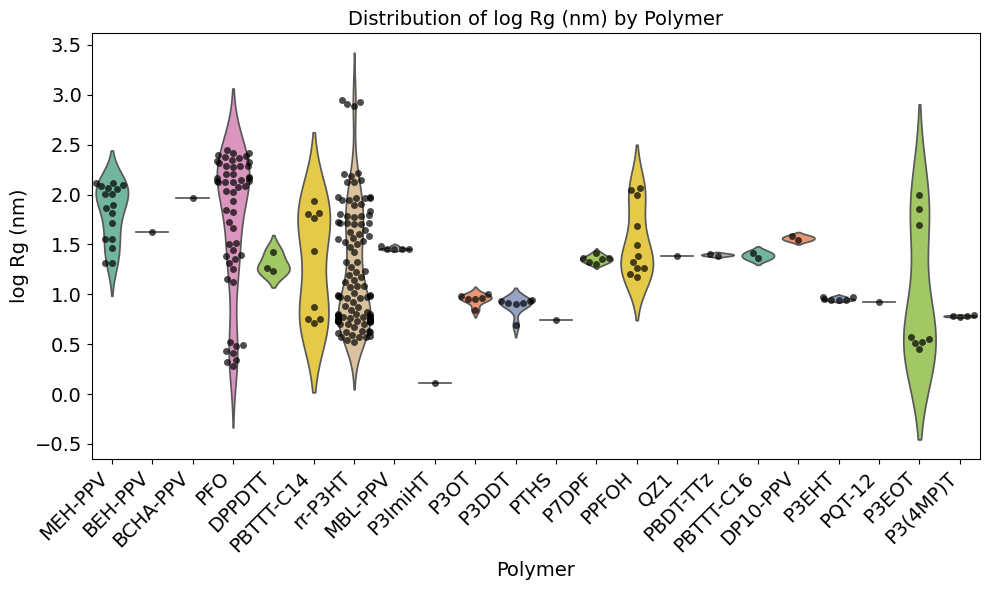

In [ ]:
plot_rg_vs_polymer(Rg_working_data_imputed_illustration,target='log Rg (nm)')

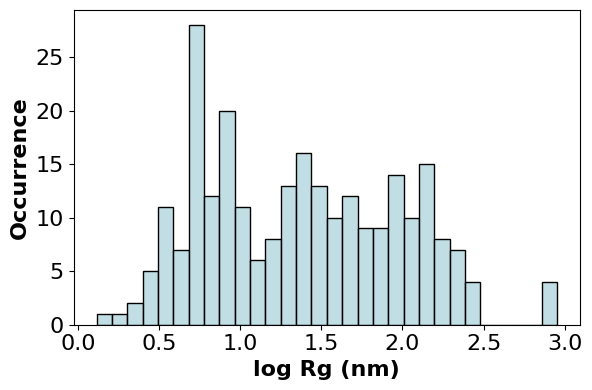

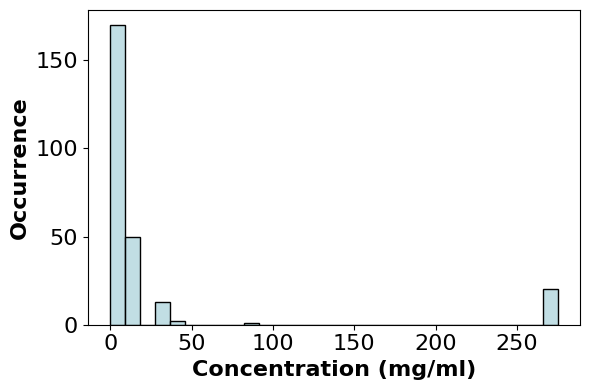

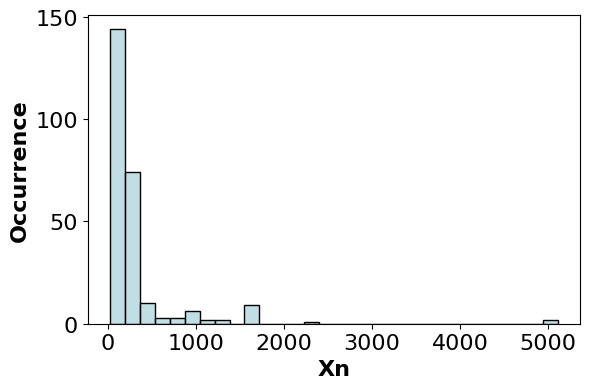

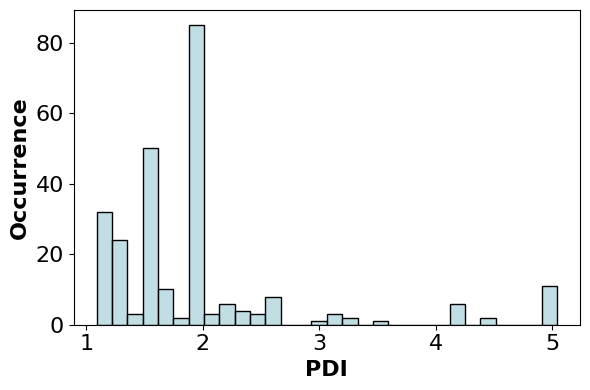

In [ ]:
def plot_distribution(data, feature, fontsize=14, figsize=(6, 4)):
    plt.figure(figsize=figsize)

    # Histogram only (barplot style)
    sns.histplot(data[feature], kde=False, bins=30, color='#ACD4DC')

    plt.ylabel('Occurrence', fontsize=fontsize, fontweight='bold')
    plt.xlabel(feature, fontsize=fontsize, fontweight='bold')
    plt.tick_params(labelsize=fontsize)

    plt.tight_layout()
    plt.show()
for feats in ['log Rg (nm)', 'Concentration (mg/ml)', 'Xn', 'PDI']:
  plot_distribution(Rg_working_data_imputed_illustration, feature=feats,fontsize=16)


# plot_distribution_with_box(clean_rg, feature='Rg1 (nm)',fontsize=16)


In [ ]:
Rg_working_data_imputed_illustration[all].describe()

,Xn,Mw (g/mol),PDI,polymer dP,polymer dD,polymer dH,solvent dP,solvent dD,solvent dH,Concentration (mg/ml),Temperature SANS/SLS/DLS/SEC (K),abs(solvent dD - polymer dD),abs(solvent dP - polymer dP),abs(solvent dH - polymer dH),Ra
count,256.000000,2.560000e+02,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000
mean,324.735213,8.589084e+04,1.965375,2.796484,17.685938,3.973047,4.656514,18.056142,6.236647,27.385557,310.260734,1.154561,2.938170,3.805947,6.185513
std,558.324222,1.558284e+05,0.898430,3.136757,0.648768,2.337926,3.508650,1.138477,8.940792,72.824297,18.830832,0.747802,2.291697,7.203638,7.037910
min,26.526730,8.681960e+03,1.090000,0.100000,16.800000,0.100000,0.000000,15.500000,0.000000,0.003500,283.000000,0.000000,0.000000,0.000000,0.807217
25%,118.361770,3.250800e+04,1.500000,1.400000,17.300000,3.325000,2.368500,17.301000,3.100000,0.735625,298.000000,0.600000,1.475000,1.000000,3.474548
50%,180.408806,4.460000e+04,1.965375,2.400000,17.600000,4.300000,4.300000,18.000000,3.300000,4.960000,301.990880,1.000000,2.900000,1.400000,5.142956
75%,295.903897,6.240000e+04,1.965375,2.400000,17.600000,4.300000,6.300000,19.200000,5.700000,10.080808,328.000000,1.600000,3.900000,3.700000,5.209607
max,5107.978047,1.330000e+06,5.040000,27.500000,20.700000,14.800000,16.400000,20.500000,42.300000,275.000000,373.000000,3.100000,21.800000,36.900000,38.939055


In [ ]:
Rg_working_data_imputed_illustration[['Rg1 (nm)','log Rg (nm)']].describe()

,Rg1 (nm),log Rg (nm)
count,256.000000,256.000000
mean,62.162449,1.378245
std,115.154955,0.603935
min,1.300000,0.113943
25%,6.625000,0.821101
50%,23.000000,1.361728
75%,78.175000,1.893065
max,897.000000,2.952792


In [ ]:
Rg_working_data_imputed_illustration[['Rg (nm)','log Rg (nm)','Concentration (mg/ml)', 'Temperature SANS/SLS/DLS/SEC (K)','PDI','Xn']].skew()


,0
Rg (nm),4.965967
log Rg (nm),0.259038
Concentration (mg/ml),3.079209
Temperature SANS/SLS/DLS/SEC (K),1.153742
PDI,2.128399
Xn,5.712985


# Categories

In [ ]:
rg_clusters_map = Rg_working_data_imputed_illustration.copy()
clean_rg=rg_clusters_map

In [ ]:
import pandas as pd
import operator


def categorical_count(df:pd.DataFrame, cat_pram):
  # Step 3: Calculate the counts for each categorical variable
  count = df[cat_pram].value_counts().sort_values(ascending=True)
  params: list[str] = count.index.to_list()

  df_count = pd.DataFrame({
    cat_pram: params,
    "count": count
     })
  return df_count


def class_summarizer(df:pd.DataFrame, cat_pram:str, count_thresholds:int,
                     comparison_threshold:list[int], comparison_operator:str)->pd.DataFrame:

    cat_df = categorical_count(df,cat_pram)
    operators = {'==': operator.eq,
                 '!=': operator.ne,
                 '<': operator.lt,
                 '<=': operator.le,
                 '>': operator.gt,
                 '>=': operator.ge}

    if comparison_operator not in operators:
        raise ValueError(f"Invalid operator {comparison_operator}. Choose from '==', '!=', '<', '<=', '>', '>='.")

    summary_data = {
         cat_pram: [f'polymers-count #{thresh}' for thresh in count_thresholds],
        'count': [len(cat_df[cat_df['count'] == thresh]) for thresh in count_thresholds]
    }
    df_summary = pd.DataFrame(summary_data)

    df_filtered = cat_df[operators[comparison_operator](cat_df['count'], comparison_threshold)]
    distribution_df = pd.concat([df_summary, df_filtered], ignore_index=True)
    distribution_df['percentage'] = distribution_df['count']/sum(distribution_df['count'])*100
    return distribution_df


In [ ]:
# polymer_categories_overall = class_summarizer(working_data, cat_pram="canonical_name",count_thresholds=[1, 2],
#                                       comparison_threshold=2, comparison_operator='>')

# polymer_categories_Rh_data = class_summarizer(clean_rg, cat_pram="canonical_name",count_thresholds=[1, 2],
#                                       comparison_threshold=2, comparison_operator='>')

polymer_categories_Rg_data = class_summarizer(clean_rg, cat_pram="canonical_name",count_thresholds=[1, 2],
                                      comparison_threshold=2, comparison_operator='>')

# polymer_categories_Lp_data = class_summarizer(clean_rg, cat_pram="canonical_name",count_thresholds=[1, 2],
#                                       comparison_threshold=2, comparison_operator='>')

In [ ]:
import re

def normalize_solvent(entry):
    if pd.isna(entry):
        return entry
    entry = str(entry).strip()
    match = re.match(r'([\d\.]+):([\d\.]+)\s*vol%\s*(.+)', entry)
    if match:
        r1, r2, solvents = match.groups()
        solvents = solvents.split('-')
        if len(solvents) == 2:
            r1, r2 = float(r1), float(r2)
            if r1 == 0 and r2 == 100:
                return solvents[1].strip()
            elif r1 == 100 and r2 == 0:
                return solvents[0].strip()
    return entry

Rg_working_data_imputed_illustration['cleaned_solvent_format'] = (
    Rg_working_data_imputed_illustration['modified_solvent_format'].map(normalize_solvent)
)


In [ ]:
Rg_working_data_imputed_illustration['cleaned_solvent_format'].unique()

array(['pXyl', '97:3 vol% Tol-EtOH', '94:6 vol% Tol-EtOH',
       '89:11 vol% Tol-EtOH', '80:20 vol% Tol-EtOH',
       '67:33 vol% Tol-EtOH', 'CF', 'oDCB', 'H2O', 'Tol',
       '70:30 vol% Tol-nC9', '79.4:20.6 vol% nC12-oDCB',
       '89.6:10.4 vol% nC12-oDCB', '54.8:45.2 vol% nC12-oDCB', 'DMSO',
       'CB', 'THF', '20:80 vol% Tol-CF', '40:60 vol% Tol-CF',
       '60:40 vol% Tol-CF', '80:20 vol% Tol-CF', '95:5 vol% Tol-CF',
       '20:80 vol% THF-CF', 'mXyl', 'nC12', 'Styr', 'B', 'CHxn',
       '20:80 vol% nC6-CF', '40:60 vol% nC6-CF', 'BB'], dtype=object)

In [ ]:
from collections import Counter
import re

def plot_solvent_counts(df, column_name, fontsize=16):
    """
    Plots a bar chart showing frequency of solvents in a dataset.
    Handles mixed solvents with vol% notation and excludes 0% components.

    - Gray bars: solvents with count > 2
    - Red bars: aggregated 'solvents_count #1' and 'solvents_count #2'
    - Right y-axis shows percentage of total occurrences (based on all solvent mentions)
    """

    def extract_solvents(entry):
        if pd.isna(entry):
            return []
        if isinstance(entry, list):
            entry = '-'.join(entry)

        match = re.match(r'((?:\d+(?:\.\d+)?)(?::\d+(?:\.\d+)?)+)\s*vol%\s*(.+)', entry, re.IGNORECASE)
        if match:
            ratios = match.group(1).split(':')
            solvents = match.group(2).split('-')
            if len(ratios) == len(solvents):
                return [s.strip() for r, s in zip(ratios, solvents) if float(r) > 0]
            else:
                return [s.strip() for s in solvents]
        else:
            return [s.strip() for s in entry.split('-') if s.strip()]

    # Step 1: Extract and count solvents
    all_solvents = []
    for entry in df[column_name]:
        all_solvents.extend(extract_solvents(entry))

    solvent_counts = Counter(all_solvents)
    print(len(solvent_counts))
    true_total = sum(solvent_counts.values())  # Total mentions

    # Step 2: Group rare solvents
    grouped_counts = {}
    solvents_count_1 = 0
    solvents_count_2 = 0

    for solvent, count in solvent_counts.items():
        if count == 1:
            solvents_count_1 += 1
        elif count == 2:
            solvents_count_2 += 1
        else:
            grouped_counts[solvent] = count

    if solvents_count_1 > 0:
        grouped_counts['solvents-count #1'] = solvents_count_1
    if solvents_count_2 > 0:
        grouped_counts['solvents-count #2'] = solvents_count_2

    # Step 3: Compute counts and percentages over total mentions
    counts = list(grouped_counts.values())
    labels = list(grouped_counts.keys())
    percentages = [count / true_total * 100 for count in counts]

    # Step 4: Sort by percentage ascending
    sorted_data = sorted(zip(labels, counts, percentages), key=lambda x: x[2])
    labels, counts, percentages = zip(*sorted_data)

    # Step 5: Assign colors
    bar_colors = [
        'red' if name in ['solvents-count #1', 'solvents-count #2'] else 'gray'
        for name in labels
    ]

    # Step 6: Plot
    fig, ax1 = plt.subplots(figsize=(8, 6))
    bar_positions = np.arange(len(labels))
    bars = ax1.bar(bar_positions, counts, color=bar_colors)

    ax1.set_ylabel('Occurrence', fontsize=fontsize, fontweight='bold')
    ax1.set_xlabel('Solvent', fontsize=fontsize, fontweight='bold')
    ax1.set_xticks(bar_positions)
    ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=fontsize+1)

    # Right y-axis for percentage
    ax2 = ax1.twinx()
    ax2.set_ylim(0, 30)
    ax2.set_ylabel('Percentage (%)', fontsize=fontsize,fontweight='bold')
    ax2.set_yticks(np.arange(0, 35, 5))
    ax2.set_yticklabels([f'{y:.0f}' for y in np.arange(0, 35, 5)])

    # Grid and layout
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


17


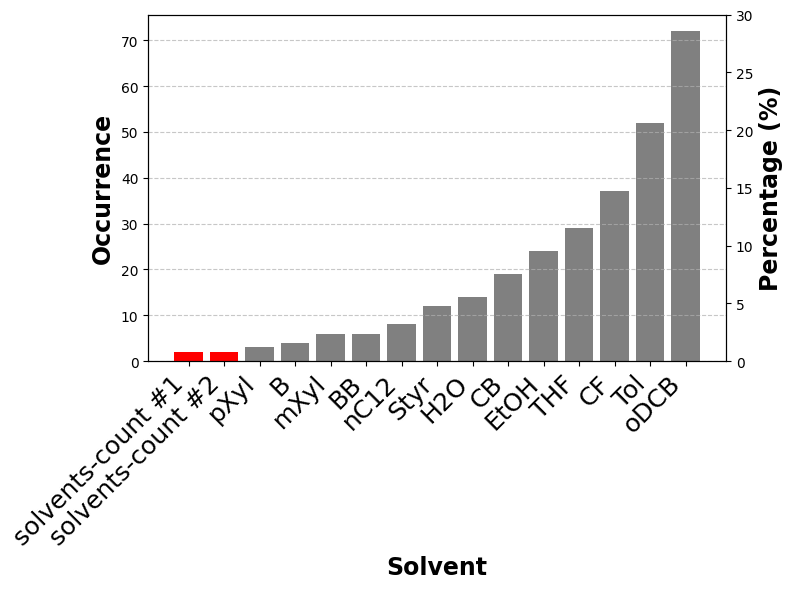

In [ ]:
plot_solvent_counts(Rg_working_data_imputed_illustration, 'cleaned_solvent_format',fontsize=17)

In [ ]:
def plot_modified_solvent_counts(df, column_name='cleaned_solvent_format', fontsize=14,figsize=(11, 6)):
    solvent_counts = df[column_name].value_counts()
    percentages = solvent_counts / solvent_counts.sum() * 100

    sorted_data = solvent_counts.sort_values(ascending=True)
    sorted_percentages = percentages.loc[sorted_data.index]

    fig, ax1 = plt.subplots(figsize=figsize)
    bar_positions = np.arange(len(sorted_data))
    bars = ax1.bar(bar_positions, sorted_data.values, color="gray")

    ax1.set_ylabel("Occurrence", fontsize=fontsize, fontweight="bold")
    ax1.set_xlabel("Solvent", fontsize=fontsize, fontweight="bold")
    ax1.set_xticks(bar_positions)
    ax1.set_xticklabels(sorted_data.index, rotation=45, ha="right", fontsize=fontsize-1)

    ax2 = ax1.twinx()
    ax2.set_ylim(0, sorted_percentages.max() * 1.1)
    ax2.set_ylabel("Percentage (%)", fontsize=fontsize, fontweight="bold")


    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


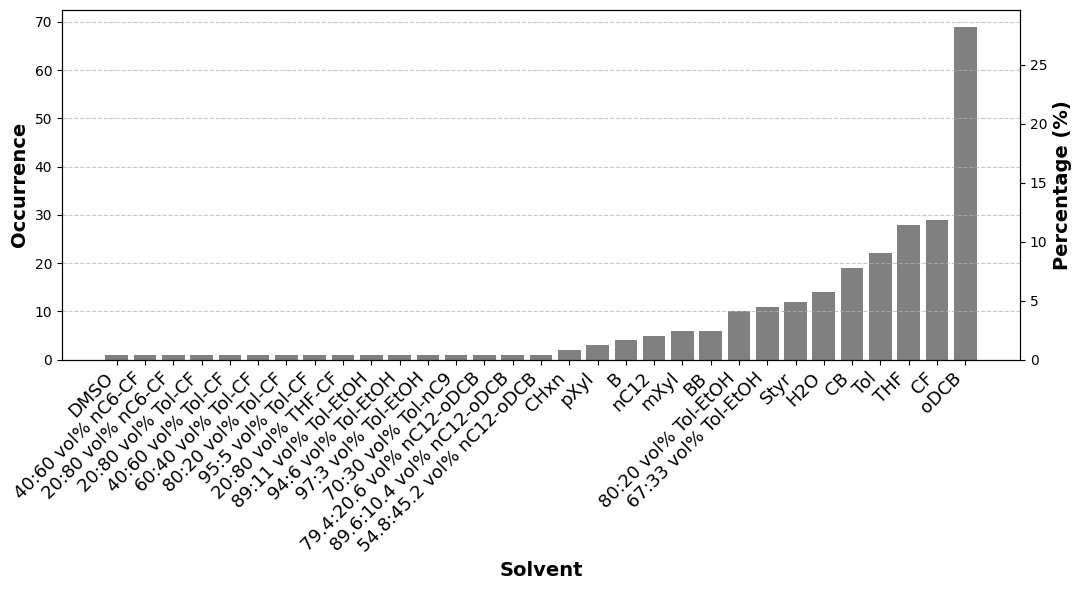

In [ ]:
plot_modified_solvent_counts(Rg_working_data_imputed_illustration)


#__EXTRA

<Axes: xlabel='Concentration (mg/ml)', ylabel='log Rg (nm)'>

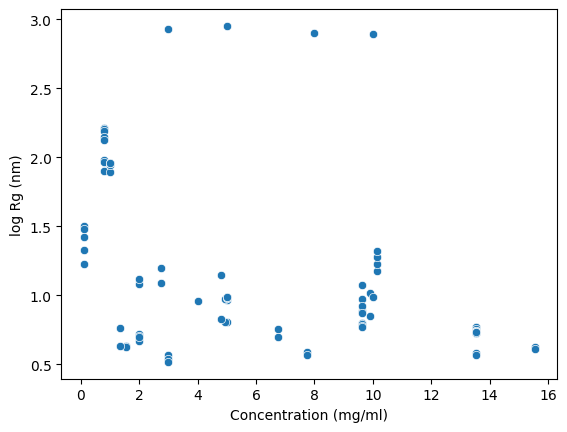

In [ ]:
temperaty = Rg_working_data_imputed_illustration.copy()
p3ht= temperaty[temperaty['canonical_name']=='rr-P3HT']
f3 = p3ht[p3ht["Concentration (mg/ml)"] < 30]
sns.scatterplot(data=f3, x='Concentration (mg/ml)', y='log Rg (nm)')

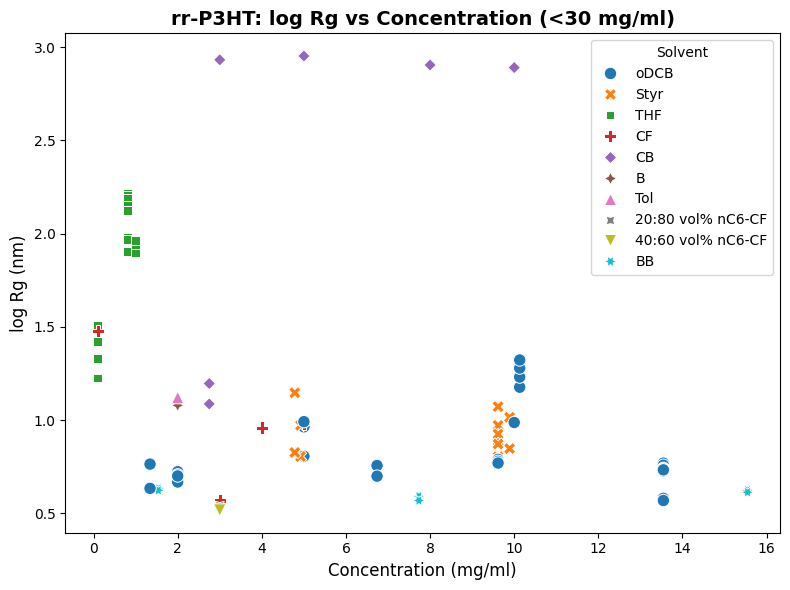

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=f3,
    x='Concentration (mg/ml)',
    y='log Rg (nm)',
    hue='cleaned_solvent_format',  # separate by solvent
    style='cleaned_solvent_format', # optional: different markers
    palette='tab10',                # nice color set
    s=80                            # point size
)

plt.title("rr-P3HT: log Rg vs Concentration (<30 mg/ml)", fontsize=14, fontweight='bold')
plt.xlabel("Concentration (mg/ml)", fontsize=12)
plt.ylabel("log Rg (nm)", fontsize=12)
plt.legend(title="Solvent", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# barh showing the categories
def barh_plot(data:pd.DataFrame, category:str,
              title:str, title_size:int=16,text_size:int=14,
              fig_size=(6,15), color_specification:List=None)->None:
  if color_specification is not None:
    colors = ['red' if name in color_specification else 'gray' for name in data[category]]
  else:
    colors = ['gray'] * len(data)

  sns.set(style="whitegrid")
  f, ax = plt.subplots(figsize=fig_size)
  sns.barplot(x="count", y=category, data=data, palette=colors, orient="h")
  plt.title(title,fontsize=title_size)
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=text_size)
  plt.show()

In [ ]:
def plot_bar(data: pd.DataFrame, category: str,
             title: str, text_size: int = 14,
             fig_size=(11,8), color_specification: List = None):

    # Define colors based on category
    if color_specification is not None:
        colors = ['red' if name in color_specification else 'gray' for name in data[category]]
    else:
        colors = ['gray'] * len(data)

    # Create figure and axis
    fig, ax1 = plt.subplots(figsize=fig_size)

    # Bar plot
    ax1.bar(data[category], data["count"], color=colors, label='Missing Percentage')

    # Set labels with custom font sizes
    ax1.set_xlabel("Polymer", fontsize=text_size,fontweight='bold')
    ax1.set_ylabel("Occurrence", fontsize=text_size,fontweight='bold')
    # ax1.set_title(title, fontsize=title_size)

    # Set tick labels font size
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=text_size+1)
    ax1.tick_params(axis='y', labelsize=text_size)

    # Add secondary y-axis
    ax1_twin = ax1.twinx()
    ax1_twin.set_ylabel("Percentage (%)", fontsize=text_size,fontweight='bold')
    ax1_twin.set_ylim(0,50)
    ax1_twin.tick_params(axis='y', labelsize=text_size)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
# plot_bar(polymer_categories_overall, category="canonical_name",
#           title="polymer distribution in overall dataset",color_specification=['polymers_count #1', 'polymers_count #2'])

In [ ]:
polymer_categories_Rg_data

,canonical_name,count,percentage
0,polymers-count #1,6,2.371542
1,polymers-count #2,3,1.185771
2,DPPDTT,3,1.185771
3,P3(4MP)T,4,1.581028
4,MBL-PPV,5,1.976285
5,P3OT,6,2.371542
6,P3EHT,6,2.371542
7,P7DPF,6,2.371542
8,P3DDT,7,2.766798
9,P3EOT,8,3.162055


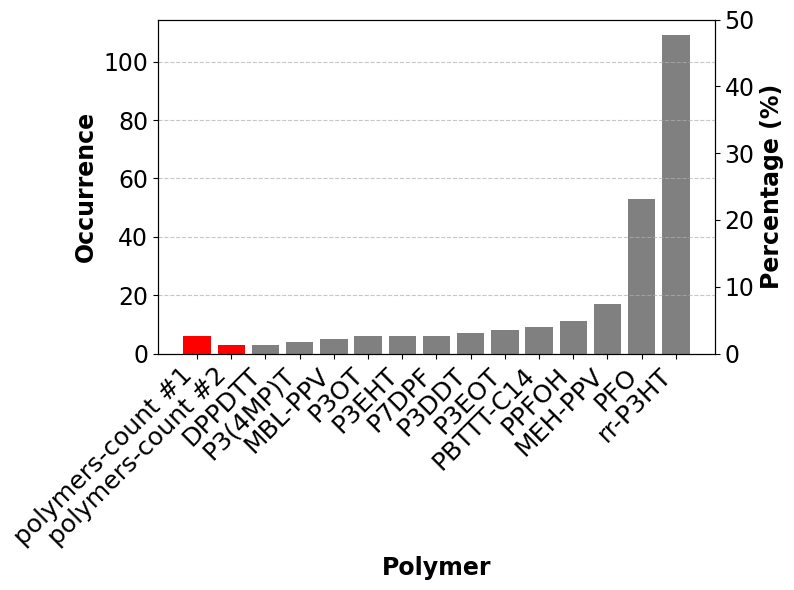

In [ ]:
plot_bar(polymer_categories_Rg_data, category="canonical_name",
          title="Polymer distribution in Rg dataset",color_specification=['polymers-count #1', 'polymers-count #2'],
         text_size=17,fig_size=(8,6))

In [ ]:
plot_bar(polymer_categories_Rh_data, category="canonical_name",
          title="polymer distribution in Rh dataset",color_specification=['polymers_count #1', 'polymers_count #2'])

NameError: name 'polymer_categories_Rh_data' is not defined

In [ ]:
plot_bar(polymer_categories_Lp_data, category="canonical_name",
          title="polymer distribution in Lp dataset",color_specification=['polymers_count #1', 'polymers_count #2'])


NameError: name 'polymer_categories_Lp_data' is not defined

In [ ]:
barh_plot(polymer_categories_Rh_data, category="canonical_name",
          title="polymer distribution in Rh dataset",color_specification=['polymers_count #1', 'polymers_count #2'])

In [ ]:
barh_plot(polymer_categories_Rg_data, category="canonical_name",
          title="polymer distribution in Rg dataset",color_specification=['polymers_count #1', 'polymers_count #2'])

#__OLD_Processing parameters analysis

In [ ]:
MEH_PPV_Rh_data = imputed_Rh_data[imputed_Rh_data['canonical_name']=='MEH-PPV']
MEH_PPV_Rg_data = imputed_Rg_data[imputed_Rg_data['canonical_name']=='MEH-PPV']

P3HT_Rh_data = imputed_Rh_data[imputed_Rh_data['canonical_name']=='rr-P3HT']
P3HT_Rg_data = imputed_Rg_data[imputed_Rg_data['canonical_name']=='rr-P3HT']

PFO_Rh_data = imputed_Rh_data[imputed_Rh_data['canonical_name']=='PFO']
PFO_Rg_data = imputed_Rg_data[imputed_Rg_data['canonical_name']=='PFO']

In [ ]:
def plot_single_distribution(data: pd.DataFrame,
                                  feature: str,
                                  title: str,
                                  x_label: str,
                                  transform_function: callable = None) -> None:
    """
    Plots a single distribution and box plot for a given feature with optional transformation.

    Args:
        data (pd.DataFrame): Data containing the feature to be plotted.
        feature (str): Name of the feature to plot.
        title (str): Title of the plot.
        x_label (str): Label for the x-axis.
        fname (str): Name of the output file.
        saving_dir (Path): Directory to save the plot.
        transform_function (callable): Transformation function to apply to the data (e.g., np.log2).
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Apply transformation function if provided
    transformed_data = transform_function(data[feature]) if transform_function else data[feature]

    # Plot histogram with optional KDE
    sns.histplot(transformed_data, kde=True, ax=ax)
    ax.set_xlabel(x_label)  # Set the label for x-axis
    ax.set_ylabel('Occurrence')  # Set the label for y-axis
    ax.set_title(title)  # Set the title for the plot

    # Create inset box plot
    box_inset = ax.inset_axes([0.01, -0.35, 0.99, 0.2])  # Adjust position for the inset box plot
    sns.boxplot(x=transformed_data, ax=box_inset, color='#259AC1')

    # Customize the inset box plot
    box_inset.set(yticks=[], xlabel=None)  # Remove y-ticks and x-label from the box plot
    box_inset.tick_params(axis='x', labelsize=10)

    # Ensure saving directory exists

    # Save the plot

    # Close the plot to free memory
    plt.show()

In [ ]:
# plot_single_distribution(MEH_PPV_Rh_data, 'Rh (IW avg log)', transform_function=np.log10, title="distribution of Rh in MEH-PPV",
#                                x_label="log10(Rh)")

In [ ]:
plot_single_distribution(P3HT_Rg_data, 'log Rg (nm)', title="distribution of Rg in P3HT",
                               x_label="log (Rg)")

In [ ]:
plot_single_distribution(PFO_Rg_data, 'log Rg (nm)', title="distribution of Rg in PFO",
                               x_label="log (Rg)")

In [ ]:
plot_single_distribution(MEH_PPV_Rg_data, 'log Rg (nm)', title="distribution of Rg in MEH-PPV",
                               x_label="log (Rg)")

## Fixing Parameters

## fixed parameters for Rh

In [ ]:
plot_hist_scatter_over_parameters_with_fixed_params(df=MEH_PPV_Rh_data, varying_params=sensetive_processing_parameters,fixed_params=fixed_params,target="Rh (IW avg log)", polymer="MEH-PPV")

In [ ]:
plot_hist_scatter_over_parameters_with_fixed_params(df=P3HT_Rh_data, varying_params=sensetive_processing_parameters,fixed_params=fixed_params,target="Rh (IW avg log)", polymer="P3HT")

## fixed parameters for Rg

In [ ]:
plot_hist_scatter_over_parameters_with_fixed_params(df=MEH_PPV_Rg_data, varying_params=sensetive_processing_parameters,fixed_params=fixed_params,target="Rg1 (nm)", polymer="MEH-PPV")

In [ ]:
plot_hist_scatter_over_parameters_with_fixed_params(df=P3HT_Rg_data, varying_params=sensetive_processing_parameters,fixed_params=fixed_params,target="Rg1 (nm)", polymer="P3HT")

## Not Fixed

In [ ]:
plot_hist_scatter_over_parameters(df=MEH_PPV_Rh_data, paramets=sensetive_processing_parameters,target="Rh (IW avg log)", polymer="MEH-PPV")

In [ ]:
plot_hist_scatter_over_parameters(df=MEH_PPV_Rg_data, paramets=sensetive_processing_parameters,target="Rg1 (nm)", polymer="MEH-PPV")

In [ ]:
plot_hist_scatter_over_parameters(df=P3HT_Rh_data, paramets=sensetive_processing_parameters,target="Rh (IW avg log)", polymer="P3HT")

In [ ]:
plot_hist_scatter_over_parameters(df=P3HT_Rg_data, paramets=sensetive_processing_parameters,target="Rg1 (nm)", polymer="P3HT")

In [ ]:
plot_hist_scatter_over_parameters(df=PFO_Rh_data, paramets=sensetive_processing_parameters,target="Rh (IW avg log)", polymer="PFO")

In [ ]:
plot_hist_scatter_over_parameters(df=PFO_Rg_data, paramets=sensetive_processing_parameters,target="Rg1 (nm)", polymer="PFO")
